## DATA EXTRACTION

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

# Facebook data
data_facebook = '/content/drive/MyDrive/Dead/facebook_afcon_ULTRA_20260208_095105.json'

# Reddit batch files
data_redit = [
    '/content/drive/MyDrive/Dead/soccer_batch001_full_20260209.json',
    '/content/drive/MyDrive/Dead/soccer_batch002_full_20260209.json',
    '/content/drive/MyDrive/Dead/soccer_batch003_full_20260210.json',
    '/content/drive/MyDrive/Dead/soccer_batch004_full_20260210.json',
    '/content/drive/MyDrive/Dead/soccer_batch005_full_20260210.json',
    '/content/drive/MyDrive/Dead/soccer_batch006_full_20260210.json'
]

# Check files exist
for f in data_redit:
    assert os.path.exists(f), f"Missing file: {f}"

# Load + concatenate Reddit data
dfs = [pd.read_json(f) for f in data_redit]
data_all = pd.concat(dfs, ignore_index=True)


data_interaction = pd.read_json(data_facebook)


## INTERACTION ANALYSYS

In [ ]:
data_all.head()


,post_id,title,author,selftext,url,permalink,score,num_comments,created_utc,subreddit,flair,comments,created_time
0,1qzm9px,Daily Discussion,AutoModerator,# Welcome to the [r/soccer](https://old.reddit...,https://www.reddit.com/r/soccer/comments/1qzm9...,https://reddit.com/r/soccer/comments/1qzm9px/d...,16,1072,1770588063,soccer,Daily Discussion,"[{'comment_id': 'o4clxpp', 'author': 'EyeSpyGu...",2026-02-08 23:01:03
1,1qzzctl,Monday Moan,AutoModerator,"The thread for moaning about your team, refere...",https://www.reddit.com/r/soccer/comments/1qzzc...,https://reddit.com/r/soccer/comments/1qzzctl/m...,10,167,1770627659,soccer,🍺Free Talk,"[{'comment_id': 'o4gh8w9', 'author': 'Bumbothe...",2026-02-09 10:00:59
2,1qzyias,[BBC] Joe Hart explains why Dominik Szoboszlai...,Sparky-moon,[Source](https://xcancel.com/BBCSport/status/2...,https://v.redd.it/11mhrouaffig1,https://reddit.com/r/soccer/comments/1qzyias/b...,10012,297,1770624374,soccer,Quotes,"[{'comment_id': 'o4efj3p', 'author': 'AutoMode...",2026-02-09 09:06:14
3,1r00a6x,Alternate angle of Kvicha Kvaratskhelia’s firs...,Sparky-moon,[Source](https://xcancel.com/PSG_espanol/statu...,https://v.redd.it/m6zjf2fgzfig1,https://reddit.com/r/soccer/comments/1r00a6x/a...,5911,58,1770631176,soccer,Media,"[{'comment_id': 'o4eqwu7', 'author': 'AutoMode...",2026-02-09 10:59:36
4,1r04t18,"Pochettino on Harry Kane's breakthrough: ""We w...",stumpsflying,,https://v.redd.it/qzz4eb8m4hig1,https://reddit.com/r/soccer/comments/1r04t18/p...,932,102,1770645291,soccer,Media,"[{'comment_id': 'o4flgll', 'author': 'AutoMode...",2026-02-09 14:54:51


In [ ]:
import pandas as pd

comments_exploded = data_all.explode('comments')
comments_df = pd.json_normalize(comments_exploded['comments'])
comments_df['post_id'] = comments_exploded['post_id'].values
comments_df.head()

,comment_id,author,body,score,created_utc,parent_id,permalink,is_submitter,depth,parent_body,post_title,created_time,post_id
0,o4clxpp,EyeSpyGuy,Daily Squadify/Man Mark posts. Reply to the re...,1.0,1.770598e+09,t3_1qzm9px,/r/soccer/comments/1qzm9px/daily_discussion/o4...,False,0.0,,,2026-02-09 01:47:05,1qzm9px
1,o4gu4ic,LackUnlucky7640,"&gt;During his career, Juanito was involved in...",1.0,1.770659e+09,t3_1qzm9px,/r/soccer/comments/1qzm9px/daily_discussion/o4...,False,0.0,,,2026-02-09 18:39:24,1qzm9px
2,o4gspoi,TherewiIlbegoals,Between the two of them Beto and Barry have pl...,1.0,1.770658e+09,t3_1qzm9px,/r/soccer/comments/1qzm9px/daily_discussion/o4...,False,0.0,,,2026-02-09 18:32:34,1qzm9px
3,o4gzzsw,Jabari313,110 what the fuck? How long has Beto been there?,1.0,1.770660e+09,t1_o4gspoi,/r/soccer/comments/1qzm9px/daily_discussion/o4...,False,1.0,,,2026-02-09 19:07:15,1qzm9px
4,o4gp6ly,boobsenjoyer40,[Panel votes 5-0 that Chelsea penalty was give...,6.0,1.770657e+09,t3_1qzm9px,/r/soccer/comments/1qzm9px/daily_discussion/o4...,False,0.0,,,2026-02-09 18:15:47,1qzm9px


## DATA NEWS

In [ ]:
# ==========================================
# Part 1: Load and Prepare Reddit Data
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from textblob import TextBlob

print(" Loading Reddit data...")

# Load Reddit post data
reddit_post_files = [
    '/content/drive/MyDrive/Dead/soccer_batch001_full_20260209.json',
    '/content/drive/MyDrive/Dead/soccer_batch002_full_20260209.json',
    '/content/drive/MyDrive/Dead/soccer_batch003_full_20260210.json',
    '/content/drive/MyDrive/Dead/soccer_batch004_full_20260210.json',
    '/content/drive/MyDrive/Dead/soccer_batch005_full_20260210.json',
    '/content/drive/MyDrive/Dead/soccer_batch006_full_20260210.json'
]

# Load and combine all post files
reddit_posts_dfs = [pd.read_json(f) for f in reddit_post_files]
data_redit_interaction = pd.concat(reddit_posts_dfs, ignore_index=True)

print(f" Loaded {len(data_redit_interaction)} Reddit posts")

# Convert dates
data_redit_interaction['created_time'] = pd.to_datetime(data_redit_interaction['created_time'])
print(f" Time range: {data_redit_interaction['created_time'].min()} to {data_redit_interaction['created_time'].max()}")

📊 Loading Reddit data...
✅ Loaded 6998 Reddit posts
📅 Time range: 2026-01-11 19:14:03 to 2026-02-10 04:43:53


In [ ]:
# ==========================================
# Part 2: Extract Comments Data
# ==========================================

print("\n Extracting comments data...")

# Explode the comments column to separate rows for each comment
comments_exploded = data_redit_interaction.explode('comments')

# Normalize the nested comments JSON into a DataFrame
comments_df = pd.json_normalize(comments_exploded['comments'])
comments_df['post_id'] = comments_exploded['post_id'].values

# Convert comment dates
comments_df['created_time'] = pd.to_datetime(comments_df['created_utc'], unit='s')

print(f" Extracted {len(comments_df)} comments")
print(f" Comments per post: {len(comments_df) / len(data_redit_interaction):.1f}")

# Show basic info
print("\n Comments DataFrame columns:")
print(comments_df.columns.tolist())
print("\n Comments data sample:")
print(comments_df[['author', 'body', 'score', 'created_time']].head(3))


📝 Extracting comments data...
✅ Extracted 291573 comments
📊 Comments per post: 41.7

📋 Comments DataFrame columns:
['comment_id', 'author', 'body', 'score', 'created_utc', 'parent_id', 'permalink', 'is_submitter', 'depth', 'parent_body', 'post_title', 'created_time', 'post_id']

📊 Comments data sample:
             author                                               body  score  \
0         EyeSpyGuy  Daily Squadify/Man Mark posts. Reply to the re...    1.0   
1   LackUnlucky7640  &gt;During his career, Juanito was involved in...    1.0   
2  TherewiIlbegoals  Between the two of them Beto and Barry have pl...    1.0   

         created_time  
0 2026-02-09 00:47:05  
1 2026-02-09 17:39:24  
2 2026-02-09 17:32:34  


In [ ]:
# ==========================================
# Part 3: Sentiment Analysis Setup
# ==========================================

print("\n🔍 Setting up sentiment analysis...")

def analyze_sentiment(text):
    """
    Analyze sentiment of text using TextBlob
    Returns polarity score between -1 (negative) and 1 (positive)
    """
    if pd.isna(text) or str(text).strip() == '':
        return 0
    try:
        analysis = TextBlob(str(text))
        return analysis.sentiment.polarity
    except:
        return 0

def categorize_sentiment(score):
    """
    Categorize sentiment score into Positive, Negative, or Neutral
    """
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to post titles
print("Analyzing post titles...")
data_redit_interaction['title_sentiment'] = data_redit_interaction['title'].apply(analyze_sentiment)
data_redit_interaction['title_sentiment_cat'] = data_redit_interaction['title_sentiment'].apply(categorize_sentiment)

# Apply sentiment analysis to comments
print("Analyzing comments...")
comments_df['comment_sentiment'] = comments_df['body'].apply(analyze_sentiment)
comments_df['comment_sentiment_cat'] = comments_df['comment_sentiment'].apply(categorize_sentiment)

print(" Sentiment analysis completed!")


🔍 Setting up sentiment analysis...
Analyzing post titles...
Analyzing comments...
✅ Sentiment analysis completed!



📈 Creating daily activity visualizations...


<Figure size 1400x1000 with 0 Axes>

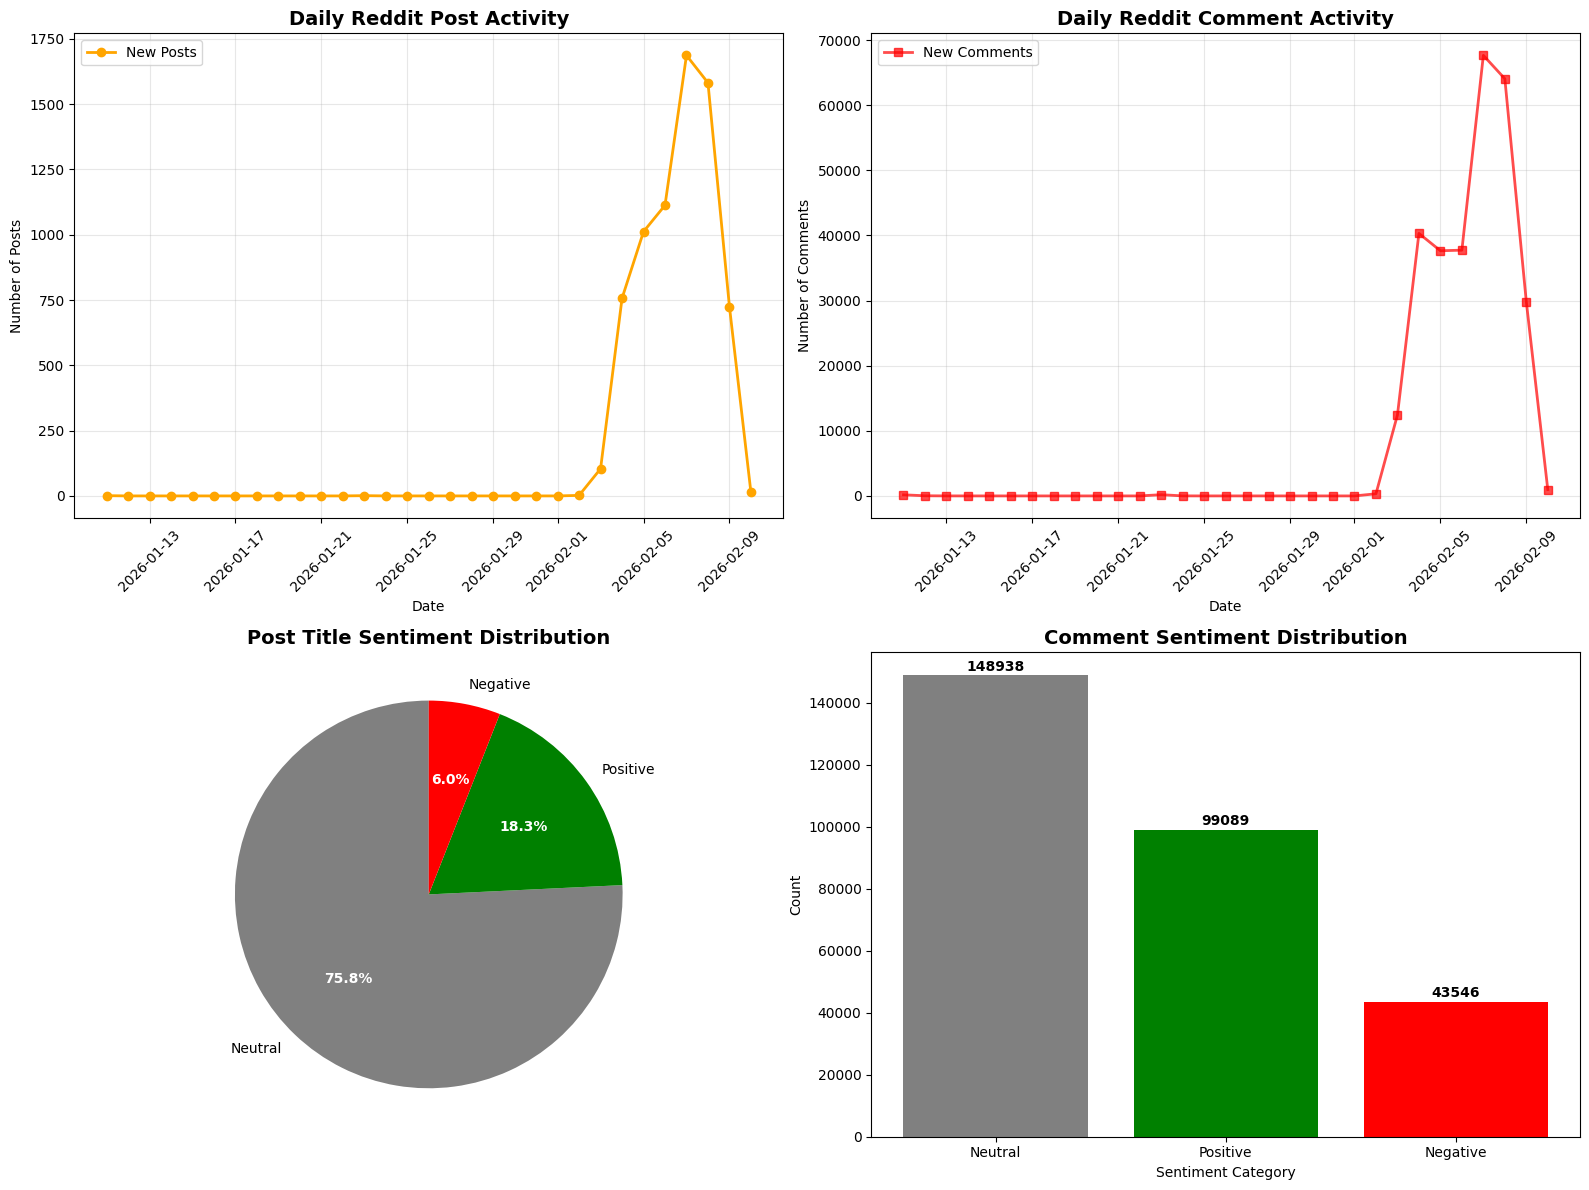

✅ Daily activity visualizations created!


In [ ]:
# ==========================================
# Part 4: Daily Activity Trends Visualization
# ==========================================

print("\n Creating daily activity visualizations...")

plt.figure(figsize=(14, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Reddit Daily Post Activity
ax1 = axes[0, 0]
reddit_daily = data_redit_interaction.set_index('created_time').resample('D').size()

ax1.plot(reddit_daily.index, reddit_daily.values, marker='o', linewidth=2,
         color='orange', label='New Posts')
ax1.set_title('Daily Reddit Post Activity', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Posts')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Reddit Daily Comment Activity
ax2 = axes[0, 1]
reddit_comments_daily = comments_df.set_index('created_time').resample('D').size()

ax2.plot(reddit_comments_daily.index, reddit_comments_daily.values, marker='s',
         linewidth=2, color='red', alpha=0.7, label='New Comments')
ax2.set_title('Daily Reddit Comment Activity', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Comments')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Post Title Sentiment Distribution
ax3 = axes[1, 0]
sentiment_counts = data_redit_interaction['title_sentiment_cat'].value_counts()
colors = {'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'}
sentiment_colors = [colors.get(x, 'blue') for x in sentiment_counts.index]

wedges, texts, autotexts = ax3.pie(sentiment_counts.values, labels=sentiment_counts.index,
                                   autopct='%1.1f%%', colors=sentiment_colors, startangle=90)
ax3.set_title('Post Title Sentiment Distribution', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 4. Comment Sentiment Distribution
ax4 = axes[1, 1]
comment_sentiment_counts = comments_df['comment_sentiment_cat'].value_counts()
comment_colors = [colors.get(x, 'blue') for x in comment_sentiment_counts.index]

ax4.bar(comment_sentiment_counts.index, comment_sentiment_counts.values,
        color=comment_colors)
ax4.set_title('Comment Sentiment Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Sentiment Category')
ax4.set_ylabel('Count')
for i, v in enumerate(comment_sentiment_counts.values):
    ax4.text(i, v + max(comment_sentiment_counts.values)*0.01, str(v),
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Daily activity visualizations created!")


🔥 Analyzing hot topics...


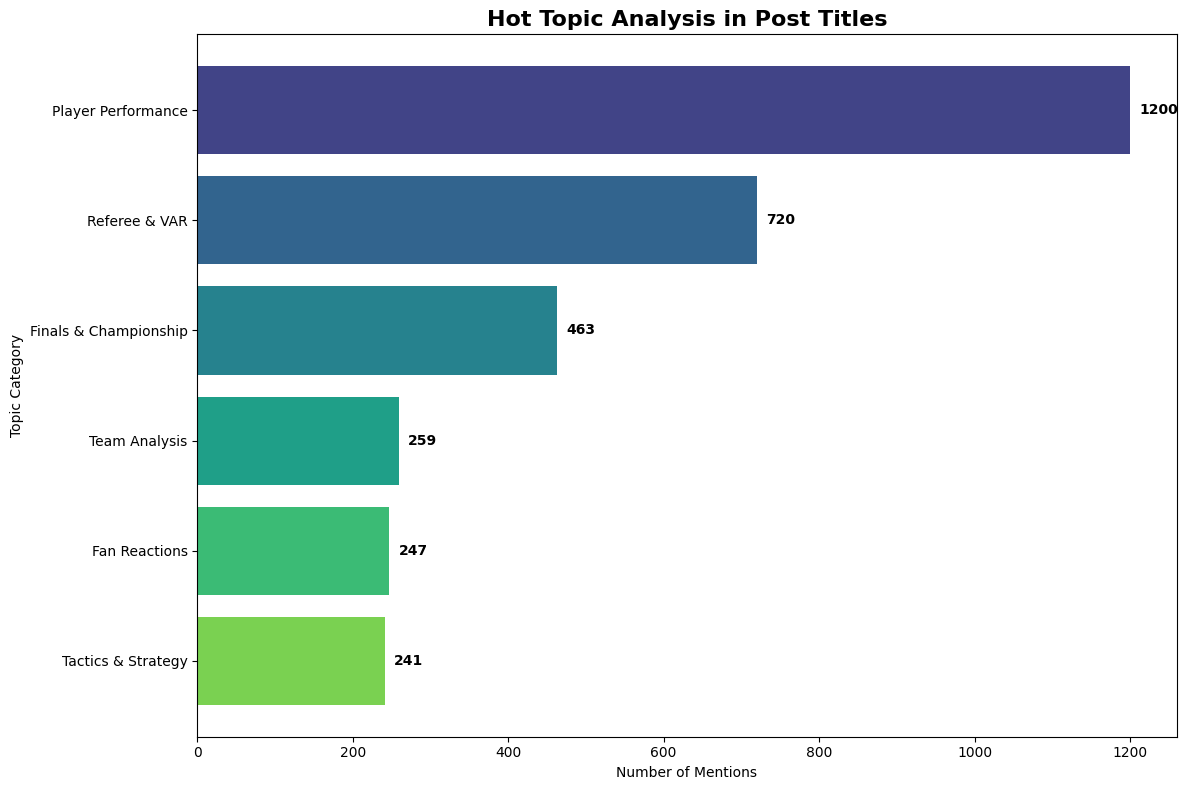

✅ Hot topic analysis completed!


In [ ]:
# ==========================================
# Part 5: Hot Topic Analysis Visualization
# ==========================================

print("\n Analyzing hot topics...")

def extract_keywords(text, keyword_list):
    """Count keyword mentions in text"""
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    count = 0
    for keyword in keyword_list:
        if keyword in text_lower:
            count += 1
    return count

# Define football-related topics
topics = {
    'Finals & Championship': ['final', 'championship', 'trophy', 'winner', 'cup', 'champion'],
    'Player Performance': ['goal', 'assist', 'penalty', 'injury', 'performance', 'score', 'player'],
    'Tactics & Strategy': ['tactic', 'formation', 'strategy', 'coach', 'manager', 'lineup', 'system'],
    'Referee & VAR': ['referee', 'var', 'penalty', 'controversy', 'decision', 'foul', 'card'],
    'Fan Reactions': ['fan', 'support', 'celebration', 'disappointed', 'cheer', 'crowd', 'atmosphere'],
    'Team Analysis': ['team', 'squad', 'selection', 'starting', 'substitute', 'defense', 'attack']
}

# Analyze topics in post titles
topic_data = []
for topic_name, keywords in topics.items():
    count = data_redit_interaction['title'].apply(lambda x: extract_keywords(x, keywords)).sum()
    topic_data.append({'Topic': topic_name, 'Mention Count': count})

df_topics = pd.DataFrame(topic_data).sort_values('Mention Count', ascending=False)

# Create visualization
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_topics)))
bars = plt.barh(df_topics['Topic'], df_topics['Mention Count'], color=colors)

plt.title('Hot Topic Analysis in Post Titles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Mentions')
plt.ylabel('Topic Category')
plt.gca().invert_yaxis()  # Highest on top

# Add value labels
for bar, count in zip(bars, df_topics['Mention Count']):
    plt.text(count + max(df_topics['Mention Count'])*0.01,
             bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Hot topic analysis completed!")

In [ ]:
# ==========================================
# Part 6: Interaction Depth Analysis
# ==========================================

print("\n Analyzing interaction patterns...")

plt.figure(figsize=(14, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Post Score Distribution
ax1 = axes[0, 0]
score_data = data_redit_interaction['score'].clip(upper=1000)  # Limit extreme values
ax1.hist(score_data, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_title('Distribution of Post Scores (Upvotes)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Post Score')
ax1.set_ylabel('Number of Posts')
mean_score = score_data.mean()
ax1.axvline(mean_score, color='red', linestyle='--',
           label=f'Average: {mean_score:.1f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Comment Count Distribution
ax2 = axes[0, 1]
comments_data = data_redit_interaction['num_comments'].clip(upper=200)
ax2.hist(comments_data, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
ax2.set_title('Distribution of Comments per Post', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Comments')
ax2.set_ylabel('Number of Posts')
mean_comments = comments_data.mean()
ax2.axvline(mean_comments, color='red', linestyle='--',
           label=f'Average: {mean_comments:.1f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Score vs Comments Relationship
ax3 = axes[1, 0]
filtered_scores = data_redit_interaction['score'].clip(upper=500)
filtered_comments = data_redit_interaction['num_comments'].clip(upper=200)

scatter = ax3.scatter(filtered_scores, filtered_comments,
                     alpha=0.6, c='purple', edgecolors='black', linewidth=0.5)
ax3.set_title('Post Score vs Comment Count', fontsize=14, fontweight='bold')
ax3.set_xlabel('Post Score')
ax3.set_ylabel('Comment Count')
ax3.grid(True, alpha=0.3)

# Add trend line
if len(filtered_scores) > 1:
    try:
        z = np.polyfit(filtered_scores, filtered_comments, 1)
        p = np.poly1d(z)
        sorted_scores = np.sort(filtered_scores)
        ax3.plot(sorted_scores, p(sorted_scores), "r--", alpha=0.8, label='Trend Line')
        ax3.legend()
    except:
        pass

# 4. Most Active Users (Excluding bots)
ax4 = axes[1, 1]
top_authors = comments_df['author'].value_counts().head(15)
# Filter out bots and AutoModerator
top_authors = top_authors[~top_authors.index.str.contains('Auto', case=False)]
top_authors = top_authors[~top_authors.index.str.contains('bot', case=False)]
top_authors = top_authors.head(10)

if len(top_authors) > 0:
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_authors)))
    bars = ax4.barh(range(len(top_authors)), top_authors.values, color=colors)
    ax4.set_yticks(range(len(top_authors)))
    ax4.set_yticklabels(top_authors.index)
    ax4.set_title('Top 10 Most Active Commenters', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Number of Comments')
    ax4.invert_yaxis()  # Highest on top

    for i, (bar, count) in enumerate(zip(bars, top_authors.values)):
        ax4.text(count + max(top_authors.values)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 str(count), va='center', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No user data available',
             ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Most Active Commenters', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(" Interaction analysis completed!")


📅 Creating time series sentiment analysis...


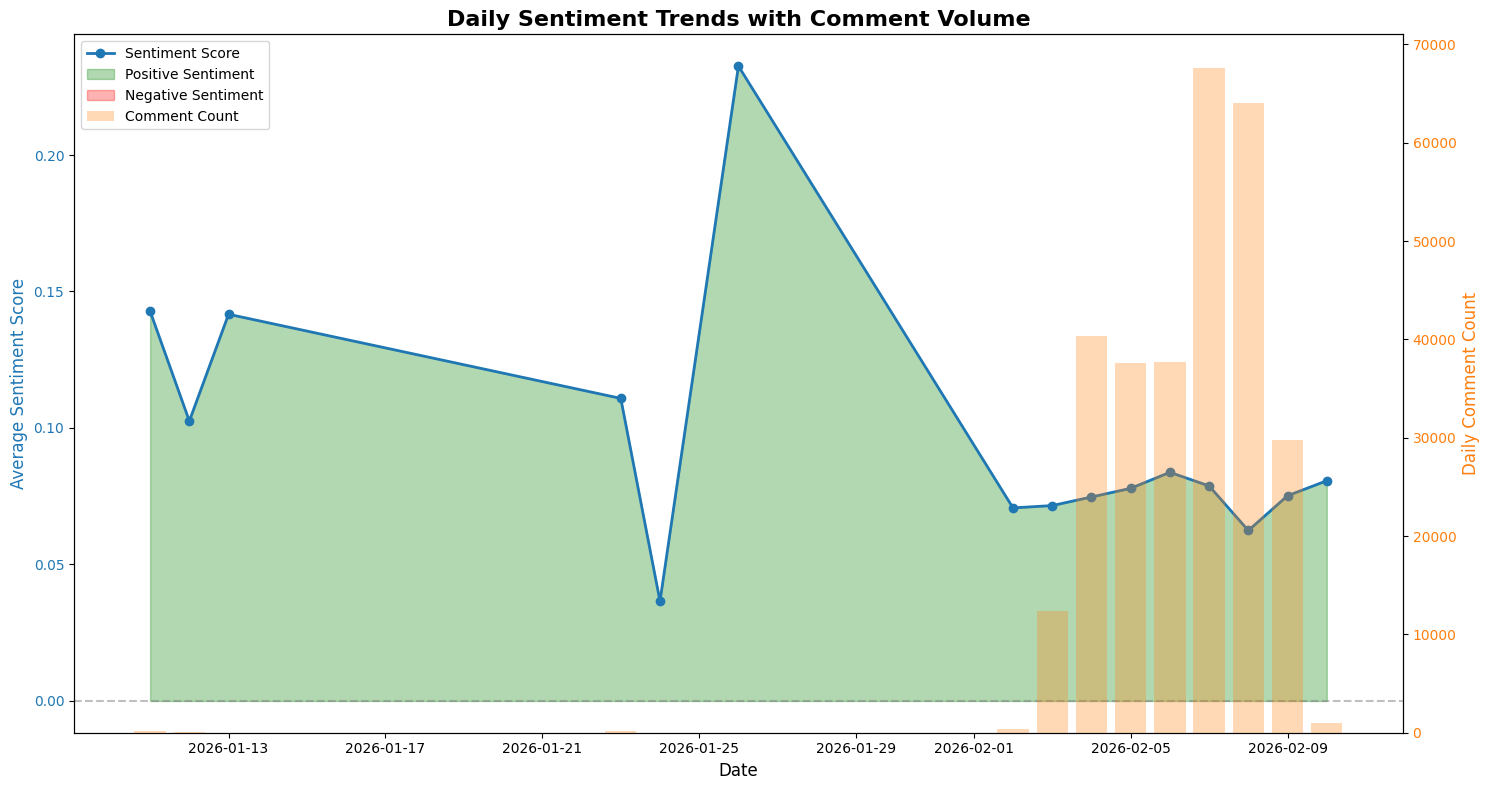

✅ Time series analysis completed!


In [ ]:
# ==========================================
# Part 7: Time Series Sentiment Analysis
# ==========================================

print("\nCreating time series sentiment analysis...")

# Prepare daily sentiment data
comments_df['date'] = comments_df['created_time'].dt.date
daily_sentiment = comments_df.groupby('date').agg({
    'comment_sentiment': 'mean',
    'comment_id': 'count'
}).rename(columns={'comment_id': 'comment_count'})

# Create dual-axis chart
fig, ax1 = plt.subplots(figsize=(15, 8))

# Line chart for sentiment
color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Average Sentiment Score', color=color1, fontsize=12)
line1 = ax1.plot(daily_sentiment.index, daily_sentiment['comment_sentiment'],
                color=color1, marker='o', linewidth=2, label='Sentiment Score')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Color fill for positive/negative areas
ax1.fill_between(daily_sentiment.index, 0, daily_sentiment['comment_sentiment'],
                where=(daily_sentiment['comment_sentiment'] > 0),
                color='green', alpha=0.3, label='Positive Sentiment')
ax1.fill_between(daily_sentiment.index, 0, daily_sentiment['comment_sentiment'],
                where=(daily_sentiment['comment_sentiment'] < 0),
                color='red', alpha=0.3, label='Negative Sentiment')

# Bar chart for comment count (secondary axis)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Daily Comment Count', color=color2, fontsize=12)
bars = ax2.bar(daily_sentiment.index, daily_sentiment['comment_count'],
              alpha=0.3, color=color2, label='Comment Count')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and formatting
plt.title('Daily Sentiment Trends with Comment Volume', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, fontsize=10)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(" Time series analysis completed!")

In [ ]:
# ==========================================
# Part 8: Generate Statistics Report
# ==========================================

print("\n" + "="*60)
print(" COMPREHENSIVE REDDIT DATA ANALYSIS REPORT")
print("="*60)

# Basic Statistics
print(f"\n BASIC STATISTICS:")
print(f"   • Total Posts: {len(data_redit_interaction):,}")
print(f"   • Total Comments: {len(comments_df):,}")
print(f"   • Average Comments per Post: {data_redit_interaction['num_comments'].mean():.1f}")
print(f"   • Average Post Score: {data_redit_interaction['score'].mean():.1f}")
print(f"   • Median Post Score: {data_redit_interaction['score'].median():.1f}")
print(f"   • Highest Scoring Post: {data_redit_interaction['score'].max():,}")

# Sentiment Analysis
print(f"\n SENTIMENT ANALYSIS:")
print(f"   • Average Post Title Sentiment: {data_redit_interaction['title_sentiment'].mean():.3f}")
print(f"   • Average Comment Sentiment: {comments_df['comment_sentiment'].mean():.3f}")
print(f"   • Post Title Distribution:")
print(f"       Positive: {(data_redit_interaction['title_sentiment_cat'] == 'Positive').sum():,} posts")
print(f"       Neutral:  {(data_redit_interaction['title_sentiment_cat'] == 'Neutral').sum():,} posts")
print(f"       Negative: {(data_redit_interaction['title_sentiment_cat'] == 'Negative').sum():,} posts")

# Temporal Analysis
print(f"\n TEMPORAL ANALYSIS:")
print(f"   • Data Collection Period: {data_redit_interaction['created_time'].min().date()} to {data_redit_interaction['created_time'].max().date()}")
print(f"   • Most Active Posting Day: {reddit_daily.idxmax().date()} ({reddit_daily.max()} posts)")
print(f"   • Most Active Commenting Day: {reddit_comments_daily.idxmax().date()} ({reddit_comments_daily.max()} comments)")
print(f"   • Average Posts per Day: {reddit_daily.mean():.1f}")
print(f"   • Average Comments per Day: {reddit_comments_daily.mean():.1f}")

# User Analysis
print(f"\n USER ENGAGEMENT ANALYSIS:")
print(f"   • Unique Post Authors: {data_redit_interaction['author'].nunique():,}")
print(f"   • Unique Comment Authors: {comments_df['author'].nunique():,}")
print(f"   • Average Comments per User: {len(comments_df) / comments_df['author'].nunique():.1f}")

# Correlation Analysis
print(f"\n CORRELATION ANALYSIS:")
try:
    correlation = data_redit_interaction['score'].corr(data_redit_interaction['num_comments'])
    print(f"   • Post Score vs Comment Count: {correlation:.3f}")
    if correlation > 0.7:
        print("     → Very Strong Positive Correlation")
    elif correlation > 0.5:
        print("     → Strong Positive Correlation")
    elif correlation > 0.3:
        print("     → Moderate Positive Correlation")
    elif correlation > 0.1:
        print("     → Weak Positive Correlation")
    elif correlation > -0.1:
        print("     → No Significant Correlation")
    else:
        print("     → Negative Correlation")
except:
    print("   • Correlation analysis not available")

# Top Topics Summary
print(f"\n TOP 5 MOST DISCUSSED TOPICS:")
for i, row in df_topics.head(5).iterrows():
    percentage = (row['Mention Count'] / len(data_redit_interaction)) * 100
    print(f"   {i+1}. {row['Topic']}: {row['Mention Count']} mentions ({percentage:.1f}% of posts)")

print("\n" + "="*60)
print(" ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*60)


📊 COMPREHENSIVE REDDIT DATA ANALYSIS REPORT

📈 BASIC STATISTICS:
   • Total Posts: 6,998
   • Total Comments: 291,573
   • Average Comments per Post: 80.3
   • Average Post Score: 500.2
   • Median Post Score: 30.0
   • Highest Scoring Post: 19,776

😊 SENTIMENT ANALYSIS:
   • Average Post Title Sentiment: 0.044
   • Average Comment Sentiment: 0.074
   • Post Title Distribution:
       Positive: 1,278 posts
       Neutral:  5,302 posts
       Negative: 418 posts

⏰ TEMPORAL ANALYSIS:
   • Data Collection Period: 2026-01-11 to 2026-02-10
   • Most Active Posting Day: 2026-02-07 (1687 posts)
   • Most Active Commenting Day: 2026-02-07 (67643 comments)
   • Average Posts per Day: 225.7
   • Average Comments per Day: 9397.2

👥 USER ENGAGEMENT ANALYSIS:
   • Unique Post Authors: 217
   • Unique Comment Authors: 15,091
   • Average Comments per User: 19.3

🔗 CORRELATION ANALYSIS:
   • Post Score vs Comment Count: 0.310
     → Moderate Positive Correlation

🔥 TOP 5 MOST DISCUSSED TOPICS:
   2


📐 Analyzing comment thread depth...

📊 THREAD DEPTH STATISTICS:
   • Max Depth: 9.0
   • Average Depth: 1.6032459819988054
   • Top-Level Comments: 102,253
   • Replies: 189,061
   • Deep Threads (>3 levels): 41,359


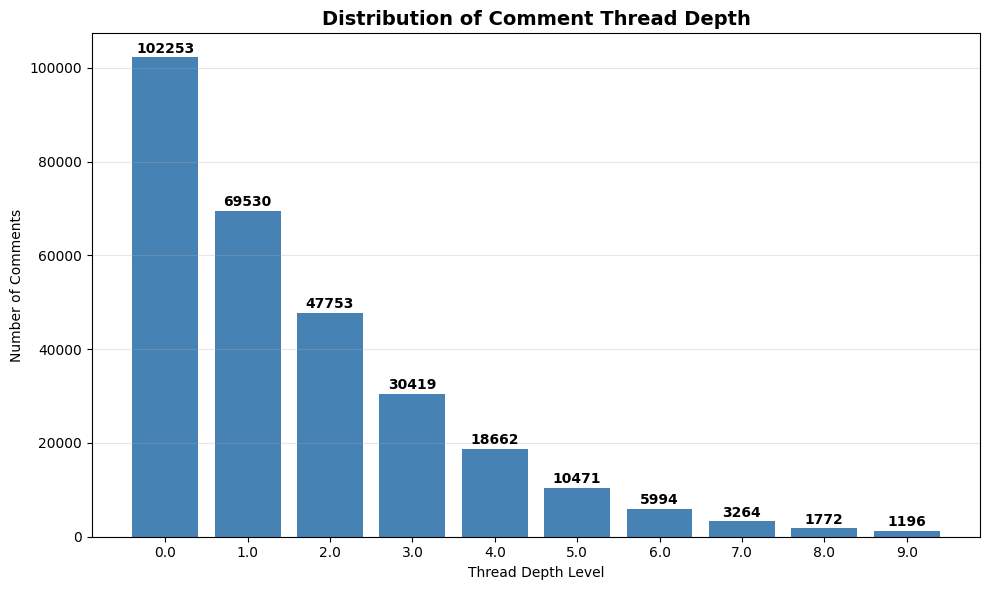


🎯 All analyses completed!


In [ ]:
# ==========================================
# Part 9: Additional Analysis - Comment Thread Depth
# ==========================================

if 'depth' in comments_df.columns:
    print("\n Analyzing comment thread depth...")

    thread_stats = {
        'Max Depth': comments_df['depth'].max(),
        'Average Depth': comments_df['depth'].mean(),
        'Top-Level Comments': (comments_df['depth'] == 0).sum(),
        'Replies': (comments_df['depth'] > 0).sum(),
        'Deep Threads (>3 levels)': (comments_df['depth'] > 3).sum()
    }

    print(f"\n THREAD DEPTH STATISTICS:")
    for key, value in thread_stats.items():
        print(f"   • {key}: {value:,}")

    # Visualize thread depth distribution
    plt.figure(figsize=(10, 6))
    depth_counts = comments_df['depth'].value_counts().sort_index().head(15)

    plt.bar(depth_counts.index.astype(str), depth_counts.values, color='steelblue')
    plt.title('Distribution of Comment Thread Depth', fontsize=14, fontweight='bold')
    plt.xlabel('Thread Depth Level')
    plt.ylabel('Number of Comments')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, (depth, count) in enumerate(depth_counts.items()):
        plt.text(i, count + max(depth_counts.values)*0.01, str(count),
                ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("\nℹ Thread depth data not available in comments DataFrame")

print("\n All analyses completed!")

## PLAYERS

In [ ]:
import json
import os
import glob
from collections import defaultdict

def collect_and_group_players_by_nationality(data_dir):
    """
    Collect data from all player JSON files and group by nationality (Senegal/Morocco)
    """
    senegal_players = []
    morocco_players = []
    other_players = []

    json_files = glob.glob(os.path.join(data_dir, "*.json"))
    json_files = [f for f in json_files if "football_news" not in f and "complete" in f]

    print(f"Found {len(json_files)} player JSON files")

    for file_path in json_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                player_data = json.load(f)
            if not isinstance(player_data, dict):
                continue

            player_info = {
                'file_name': os.path.basename(file_path),
                'player_id': player_data.get('player_id'),
                'slug': player_data.get('slug'),
                'name': extract_player_name(player_data),
                'base_url': player_data.get('base_url'),
                'scraped_at': player_data.get('scraped_at')
            }

            injuries = []
            if 'pages' in player_data and 'verletzungen' in player_data['pages']:
                injuries = player_data['pages']['verletzungen'].get('injuries_list', [])

            # Extract performance data
            performance_data = {}
            if 'pages' in player_data and 'leistungsdatendetails' in player_data['pages']:
                performance_data = extract_performance_data(player_data['pages']['leistungsdatendetails'])

            # Extract club data
            club_data = []
            if 'pages' in player_data and 'leistungsdatenverein' in player_data['pages']:
                club_data = extract_club_data(player_data['pages']['leistungsdatenverein'])

            # Extract career data
            career_data = {}
            if 'pages' in player_data and 'detaillierteleistungsdaten' in player_data['pages']:
                career_data = extract_career_data(player_data['pages']['detaillierteleistungsdaten'])

            # Extract national team data to determine nationality
            nationality = detect_nationality(player_data)
            current_club = get_current_club(player_data, club_data)

            # Compile complete player data
            complete_player_data = {
                **player_info,
                'nationality': nationality,
                'current_club': current_club,
                'injuries': injuries,
                'injury_count': len(injuries),
                'performance_summary': performance_data,
                'club_history': club_data,
                'career_stats': career_data,
                'has_profil_error': player_data.get('pages', {}).get('profil', {}).get('name') == 'Error | Transfermarkt'
            }

            # Group by nationality - USE MORE RELIABLE DETECTION
            player_name = player_info.get('name', '').lower()
            slug_name = player_info.get('slug', '').lower()

            # Common Senegal player surnames (based on your data)
            senegal_surnames = ['niakhate', 'mane', 'diallo', 'ndiaye', 'sarr', 'gueye', 'kouyate', 'diouf', 'ba', 'fall', 'ciss', 'name', 'camara', 'sy', 'mendy']

            # Common Morocco player surnames
            morocco_surnames = ['hakimi', 'ziyech', 'amrabat', 'saiss', 'mazraoui', 'amallah', 'en-nesyri', 'ounahi', 'bono', 'boufal', 'aguerd', 'el khannouss', 'sabiri', 'aboukhlal', 'ezzalzouli', 'harit', 'mmaee', 'attiyat allah', 'adli']

            # Check nationality by multiple methods
            is_senegal = False
            is_morocco = False

            # Method 1: Check detected nationality
            if 'senegal' in nationality.lower() or 'sénégal' in nationality.lower():
                is_senegal = True
            elif 'maroc' in nationality.lower() or 'morocco' in nationality.lower():
                is_morocco = True

            # Method 2: Check player surname
            if not is_senegal and not is_morocco:
                for surname in senegal_surnames:
                    if surname in player_name or surname in slug_name:
                        is_senegal = True
                        break

                for surname in morocco_surnames:
                    if surname in player_name or surname in slug_name:
                        is_morocco = True
                        break

            # Method 3: Check club history for national teams
            if not is_senegal and not is_morocco:
                if check_national_team_in_club_history(club_data):
                    if 'senegal' in str(club_data).lower() or 'sénégal' in str(club_data).lower():
                        is_senegal = True
                    elif 'maroc' in str(club_data).lower() or 'morocco' in str(club_data).lower():
                        is_morocco = True

            # Final grouping
            if is_senegal:
                senegal_players.append(complete_player_data)
                print(f"✓ SENEGAL: {player_info.get('name', 'Unknown')}")
            elif is_morocco:
                morocco_players.append(complete_player_data)
                print(f"✓ MOROCCO: {player_info.get('name', 'Unknown')}")
            else:
                other_players.append(complete_player_data)
                print(f"  OTHER: {player_info.get('name', 'Unknown')} ({nationality})")

        except json.JSONDecodeError as e:
            print(f"Error reading {file_path}: {e}")
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    return senegal_players, morocco_players, other_players

def check_national_team_in_club_history(club_data):
    """Check if club history contains national team references"""
    for club in club_data:
        club_name = club.get('club', '').lower()
        if 'sénégal' in club_name or 'senegal' in club_name or 'maroc' in club_name or 'morocco' in club_name:
            return True
    return False

def extract_player_name(player_data):
    """Extract player name from the data structure"""
    # Try to get name from profil page first
    if 'pages' in player_data and 'profil' in player_data['pages']:
        profil_data = player_data['pages']['profil']
        if 'name' in profil_data and profil_data['name'] != 'Error | Transfermarkt':
            return profil_data['name']

    # Try to get from slug
    slug = player_data.get('slug', '')
    if slug:
        # Convert slug to readable name: "moussa-niakhate" -> "Moussa Niakhate"
        return ' '.join(word.capitalize() for word in slug.split('-'))

    # Try to extract from URL
    url = player_data.get('base_url', '')
    if url:
        parts = url.split('/')
        for part in parts:
            if part and not part.startswith('http') and part not in ['spieler', 'profil', 'leistungsdaten']:
                name_part = part.replace('-profil', '').replace('-spieler', '')
                if name_part and not name_part.isdigit():
                    return ' '.join(word.capitalize() for word in name_part.split('-'))

    return 'Unknown Player'

def detect_nationality(player_data):
    """Detect player nationality from various sources in the data"""
    # Check national team data first
    if 'pages' in player_data and 'nationalmannschaft' in player_data['pages']:
        nationalmannschaft = player_data['pages']['nationalmannschaft']
        if isinstance(nationalmannschaft, dict) and 'table_1' in nationalmannschaft:
            rows = nationalmannschaft['table_1'].get('rows', [])
            if rows:
                # Check competitions that might indicate nationality
                for row in rows:
                    competition = row.get('wettbewerb', '').lower()
                    if 'senegal' in competition or 'sénégal' in competition:
                        return 'Sénégal'
                    elif 'maroc' in competition or 'morocco' in competition:
                        return 'Maroc'

    # Check profil page for nationality
    if 'pages' in player_data and 'profil' in player_data['pages']:
        profil_data = player_data['pages']['profil']
        if 'nationality' in profil_data:
            nationality = profil_data['nationality'].lower()
            if 'senegal' in nationality or 'sénégal' in nationality:
                return 'Sénégal'
            elif 'maroc' in nationality or 'morocco' in nationality:
                return 'Maroc'

    # Check player's club data for national team clubs
    if 'pages' in player_data and 'leistungsdatenverein' in player_data['pages']:
        leistungsdatenverein = player_data['pages']['leistungsdatenverein']
        if isinstance(leistungsdatenverein, dict) and 'table_1' in leistungsdatenverein:
            rows = leistungsdatenverein['table_1'].get('rows', [])
            for row in rows:
                club_name = row.get('col_2', '').lower()
                if 'sénégal' in club_name or 'senegal' in club_name:
                    return 'Sénégal'
                elif 'maroc' in club_name or 'morocco' in club_name:
                    return 'Maroc'

    return 'Unknown'

def get_current_club(player_data, club_history):
    """Extract current club from player data"""
    # First try to get from profil page
    if 'pages' in player_data and 'profil' in player_data['pages']:
        profil_data = player_data['pages']['profil']
        if 'current_club' in profil_data:
            return profil_data['current_club']

    # Then try club history (first entry is usually current club)
    if club_history and len(club_history) > 0:
        return club_history[0].get('club', 'Unknown Club')

    return 'Unknown Club'

def extract_performance_data(leistungsdatendetails_page):
    """Extract performance data from leistungsdatendetails"""
    performance_summary = {}

    if not isinstance(leistungsdatendetails_page, dict):
        return performance_summary

    for table_key, table_data in leistungsdatendetails_page.items():
        if table_key.startswith('table_'):
            rows = table_data.get('rows', [])
            for row in rows:
                if isinstance(row, dict):
                    competition = row.get('reihenfolge ASC, saison_id DESC, verein_id ASC', '')
                    if competition:
                        season = row.get('Saison', '')
                        if season not in performance_summary:
                            performance_summary[season] = []
                        performance_summary[season].append({
                            'competition': competition,
                            'appearances': row.get('col_5', ''),
                            'goals': row.get('col_6', ''),
                            'assists': row.get('col_7', ''),
                            'minutes': row.get('col_9', '')
                        })

    return performance_summary

def extract_club_data(leistungsdatenverein_page):
    """Extract club history data"""
    club_history = []

    if not isinstance(leistungsdatenverein_page, dict):
        return club_history

    if 'table_1' in leistungsdatenverein_page:
        table_data = leistungsdatenverein_page['table_1']
        rows = table_data.get('rows', [])

        for row in rows:
            if isinstance(row, dict):
                club_name = row.get('col_2', '')
                if club_name:
                    club_history.append({
                        'club': club_name,
                        'appearances': row.get('col_3', ''),
                        'goals': row.get('col_4', ''),
                        'assists': row.get('col_5', ''),
                        'minutes': row.get('col_9', '')
                    })

    return club_history

def extract_career_data(detaillierteleistungsdaten_page):
    """Extract detailed career statistics"""
    career_stats = {}

    if not isinstance(detaillierteleistungsdaten_page, dict):
        return career_stats

    for table_key, table_data in detaillierteleistungsdaten_page.items():
        if table_key.startswith('table_'):
            rows = table_data.get('rows', [])
            for row in rows:
                if isinstance(row, dict):
                    competition = row.get('reihenfolge ASC, datum DESC, saison_id DESC, verein_id ASC', '')
                    if competition:
                        season = row.get('Saison', '')
                        if season not in career_stats:
                            career_stats[season] = {}

                        if competition not in career_stats[season]:
                            career_stats[season][competition] = {
                                'appearances': row.get('col_5', ''),
                                'goals': row.get('col_6', ''),
                                'assists': row.get('col_7', ''),
                                'yellow_cards': row.get('col_8', ''),
                                'red_cards': row.get('col_9', ''),
                                'minutes': row.get('col_11', '')
                            }

    return career_stats

def save_grouped_data(senegal_players, morocco_players, other_players):
    """Save grouped player data to separate JSON files"""

    # Save Senegal players
    if senegal_players:
        with open('senegal_players.json', 'w', encoding='utf-8') as f:
            json.dump(senegal_players, f, ensure_ascii=False, indent=2)
        print(f"\n✓ Saved {len(senegal_players)} Senegal players to 'senegal_players.json'")

    # Save Morocco players
    if morocco_players:
        with open('morocco_players.json', 'w', encoding='utf-8') as f:
            json.dump(morocco_players, f, ensure_ascii=False, indent=2)
        print(f"✓ Saved {len(morocco_players)} Morocco players to 'morocco_players.json'")

    # Save other players
    if other_players:
        with open('other_players.json', 'w', encoding='utf-8') as f:
            json.dump(other_players, f, ensure_ascii=False, indent=2)
        print(f"✓ Saved {len(other_players)} other players to 'other_players.json'")

def generate_group_statistics(senegal_players, morocco_players, other_players):
    """Generate statistics for each group"""

    def group_stats(players, group_name):
        stats = {
            'group_name': group_name,
            'total_players': len(players),
            'players_with_injuries': 0,
            'total_injuries': 0,
            'players_by_club': defaultdict(int),
            'top_clubs': [],
            'players_with_performance_data': 0,
            'unique_clubs': set(),
            'injury_prone_players': []
        }

        for player in players:
            # Count players with injuries
            if player.get('injuries'):
                stats['players_with_injuries'] += 1
                stats['total_injuries'] += len(player['injuries'])

            # Track clubs
            current_club = player.get('current_club', 'Unknown')
            stats['players_by_club'][current_club] += 1
            stats['unique_clubs'].add(current_club)

            # Count players with performance data
            if player.get('performance_summary'):
                stats['players_with_performance_data'] += 1

            # Identify injury-prone players (more than 3 injuries)
            if len(player.get('injuries', [])) > 3:
                stats['injury_prone_players'].append({
                    'name': player.get('name'),
                    'injury_count': len(player.get('injuries', [])),
                    'club': current_club
                })

        # Get top 5 clubs
        stats['top_clubs'] = sorted(
            stats['players_by_club'].items(),
            key=lambda x: x[1],
            reverse=True
        )[:5]

        stats['unique_clubs'] = list(stats['unique_clubs'])

        return stats

    return {
        'senegal': group_stats(senegal_players, 'Sénégal') if senegal_players else {'group_name': 'Sénégal', 'total_players': 0},
        'morocco': group_stats(morocco_players, 'Maroc') if morocco_players else {'group_name': 'Maroc', 'total_players': 0},
        'other': group_stats(other_players, 'Autres') if other_players else {'group_name': 'Autres', 'total_players': 0}
    }

def print_group_report(statistics):
    """Print a detailed report of player groups"""

    print("\n" + "="*60)
    print("RAPPORT DES JOUEURS PAR NATIONALITÉ")
    print("="*60)

    for group_name, stats in statistics.items():
        print(f"\n📊 {stats['group_name'].upper()}")
        print("-"*40)
        print(f"Total joueurs: {stats.get('total_players', 0)}")

        if stats.get('total_players', 0) > 0:
            print(f"Joueurs avec blessures: {stats.get('players_with_injuries', 0)}")
            print(f"Total blessures: {stats.get('total_injuries', 0)}")
            print(f"Joueurs avec données de performance: {stats.get('players_with_performance_data', 0)}")
            print(f"Clubs uniques: {len(stats.get('unique_clubs', []))}")

            if stats.get('top_clubs'):
                print("\n🏆 Top 5 clubs:")
                for club, count in stats['top_clubs']:
                    print(f"  {club}: {count} joueur(s)")

            if stats.get('injury_prone_players'):
                print("\n⚠️  Joueurs souvent blessés (>3 blessures):")
                for player in stats['injury_prone_players'][:5]:  # Show top 5
                    print(f"  {player['name']} ({player['club']}): {player['injury_count']} blessures")

    print("\n" + "="*60)

def export_to_csv(senegal_players, morocco_players):
    """Export player data to CSV files for analysis"""
    import csv

    # Export Senegal players
    if senegal_players:
        with open('senegal_players.csv', 'w', newline='', encoding='utf-8') as csvfile:
            fieldnames = ['name', 'player_id', 'current_club', 'injury_count', 'nationality']
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            for player in senegal_players:
                writer.writerow({
                    'name': player.get('name'),
                    'player_id': player.get('player_id'),
                    'current_club': player.get('current_club'),
                    'injury_count': player.get('injury_count', 0),
                    'nationality': player.get('nationality')
                })
        print("✓ Exported Senegal players to 'senegal_players.csv'")

    # Export Morocco players
    if morocco_players:
        with open('morocco_players.csv', 'w', newline='', encoding='utf-8') as csvfile:
            fieldnames = ['name', 'player_id', 'current_club', 'injury_count', 'nationality']
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            for player in morocco_players:
                writer.writerow({
                    'name': player.get('name'),
                    'player_id': player.get('player_id'),
                    'current_club': player.get('current_club'),
                    'injury_count': player.get('injury_count', 0),
                    'nationality': player.get('nationality')
                })
        print("✓ Exported Morocco players to 'morocco_players.csv'")

def main():
    # Your data directory
    data_dir = '/content/drive/MyDrive/Dead/data'

    print("Collecting and grouping players by nationality...")
    print("-"*50)

    # Collect and group players
    senegal_players, morocco_players, other_players = collect_and_group_players_by_nationality(data_dir)

    # Save grouped data
    save_grouped_data(senegal_players, morocco_players, other_players)

    # Generate statistics
    statistics = generate_group_statistics(senegal_players, morocco_players, other_players)

    # Print report
    print_group_report(statistics)

    # Export to CSV
    export_to_csv(senegal_players, morocco_players)

    # Summary
    print("\n" + "="*60)
    print("RÉSUMÉ FINAL")
    print("="*60)
    print(f" Joueurs Sénégalais: {len(senegal_players)}")
    print(f" Joueurs Marocains: {len(morocco_players)}")
    print(f" Autres nationalités: {len(other_players)}")
    print(f" Total joueurs analysés: {len(senegal_players) + len(morocco_players) + len(other_players)}")

    # List some notable players from each group
    if senegal_players:
        print("\n Joueurs notables Sénégalais:")
        for player in senegal_players[:10]:  # Show more players
            print(f"  • {player.get('name')} ({player.get('current_club')}) - {player.get('injury_count')} blessures")
    else:
        print("\n Joueurs notables Sénégalais: Aucun joueur sénégalais trouvé")

    if morocco_players:
        print("\n Joueurs notables Marocains:")
        for player in morocco_players[:10]:  # Show more players
            print(f"  • {player.get('name')} ({player.get('current_club')}) - {player.get('injury_count')} blessures")
    else:
        print("\n Joueurs notables Marocains: Aucun joueur marocain trouvé")

if __name__ == "__main__":
    main()

--------------------------------------------------
Found 0 player JSON files

RAPPORT DES JOUEURS PAR NATIONALITÉ

📊 SÉNÉGAL
----------------------------------------
Total joueurs: 0

📊 MAROC
----------------------------------------
Total joueurs: 0

📊 AUTRES
----------------------------------------
Total joueurs: 0


RÉSUMÉ FINAL
🎯 Joueurs Sénégalais: 0
🎯 Joueurs Marocains: 0
🌍 Autres nationalités: 0
📊 Total joueurs analysés: 0

🔝 Joueurs notables Sénégalais: Aucun joueur sénégalais trouvé

🔝 Joueurs notables Marocains: Aucun joueur marocain trouvé


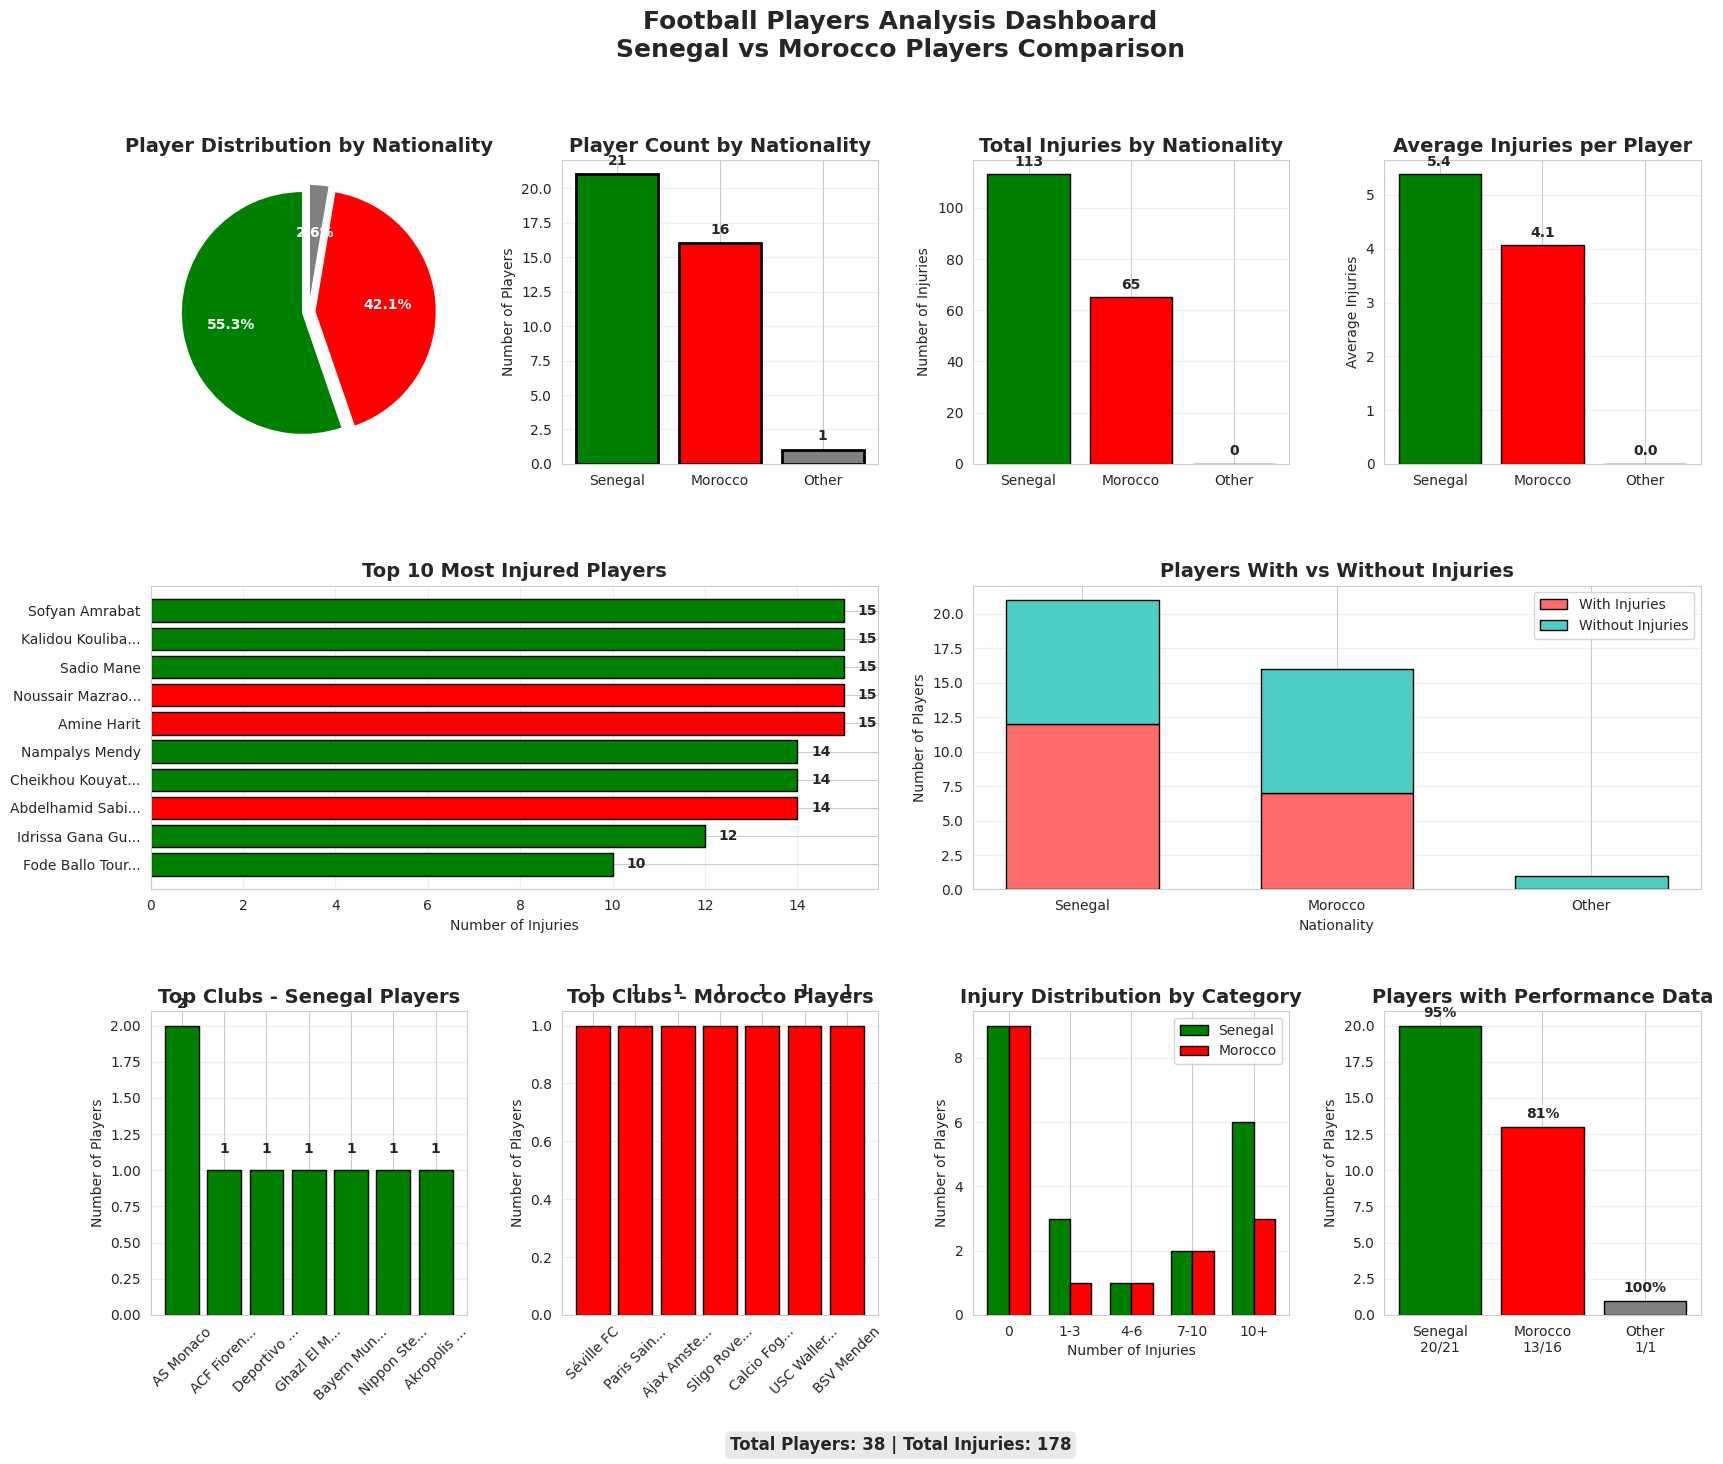

✓ Dashboard created successfully!
✓ Total Players: 38
✓ Senegal Players: 21
✓ Morocco Players: 16
✓ Other Players: 1
✓ Total Injuries: 178
✓ Chart saved as 'player_analysis_dashboard.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
from collections import defaultdict

# Load data from JSON files
def load_player_data():
    with open('senegal_players.json', 'r', encoding='utf-8') as f:
        senegal_players = json.load(f)
    with open('morocco_players.json', 'r', encoding='utf-8') as f:
        morocco_players = json.load(f)
    with open('other_players.json', 'r', encoding='utf-8') as f:
        other_players = json.load(f)
    return senegal_players, morocco_players, other_players

# Create all visualizations
def create_all_visualizations():
    # Load data
    senegal_players, morocco_players, other_players = load_player_data()

    # Set style
    plt.style.use('default')
    sns.set_style("whitegrid")

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))

    # Grid layout
    gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

    # 1. Player Distribution Pie Chart
    ax1 = fig.add_subplot(gs[0, 0])
    nationalities = ['Senegal', 'Morocco', 'Other']
    counts = [len(senegal_players), len(morocco_players), len(other_players)]
    colors = ['#008000', '#FF0000', '#808080']
    wedges, texts, autotexts = ax1.pie(counts, colors=colors, autopct='%1.1f%%',
                                       startangle=90, explode=[0.05, 0.05, 0.05])
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    ax1.set_title('Player Distribution by Nationality', fontsize=14, fontweight='bold')

    # 2. Player Count Bar Chart
    ax2 = fig.add_subplot(gs[0, 1])
    bars = ax2.bar(nationalities, counts, color=colors, edgecolor='black', linewidth=2)
    ax2.set_title('Player Count by Nationality', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Players')
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, count in zip(bars, counts):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count}', ha='center', va='bottom', fontweight='bold')

    # 3. Total Injuries Bar Chart
    ax3 = fig.add_subplot(gs[0, 2])
    senegal_injuries = sum(p.get('injury_count', 0) for p in senegal_players)
    morocco_injuries = sum(p.get('injury_count', 0) for p in morocco_players)
    other_injuries = sum(p.get('injury_count', 0) for p in other_players)
    injury_counts = [senegal_injuries, morocco_injuries, other_injuries]
    bars = ax3.bar(nationalities, injury_counts, color=colors, edgecolor='black')
    ax3.set_title('Total Injuries by Nationality', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Number of Injuries')
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, count in zip(bars, injury_counts):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(injury_counts)/50,
                f'{count}', ha='center', va='bottom', fontweight='bold')

    # 4. Average Injuries per Player
    ax4 = fig.add_subplot(gs[0, 3])
    senegal_avg = senegal_injuries / len(senegal_players) if senegal_players else 0
    morocco_avg = morocco_injuries / len(morocco_players) if morocco_players else 0
    other_avg = other_injuries / len(other_players) if other_players else 0
    avg_injuries = [senegal_avg, morocco_avg, other_avg]
    bars = ax4.bar(nationalities, avg_injuries, color=colors, edgecolor='black')
    ax4.set_title('Average Injuries per Player', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Average Injuries')
    ax4.grid(True, alpha=0.3, axis='y')
    for bar, avg in zip(bars, avg_injuries):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_injuries)/50,
                f'{avg:.1f}', ha='center', va='bottom', fontweight='bold')

    # 5. Top 10 Most Injured Players
    ax5 = fig.add_subplot(gs[1, :2])
    all_players = senegal_players + morocco_players + other_players
    top_injured = sorted(all_players, key=lambda x: x.get('injury_count', 0), reverse=True)[:10]
    names = [p.get('name', 'Unknown')[:15] + ('...' if len(p.get('name', '')) > 15 else '')
             for p in top_injured]
    injuries = [p.get('injury_count', 0) for p in top_injured]
    nat_colors = []
    for p in top_injured:
        if p in senegal_players:
            nat_colors.append('#008000')
        elif p in morocco_players:
            nat_colors.append('#FF0000')
        else:
            nat_colors.append('#808080')
    bars = ax5.barh(names, injuries, color=nat_colors, edgecolor='black')
    ax5.set_title('Top 10 Most Injured Players', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Number of Injuries')
    ax5.invert_yaxis()
    ax5.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, injuries):
        ax5.text(bar.get_width() + max(injuries)/50, bar.get_y() + bar.get_height()/2,
                f'{val}', ha='left', va='center', fontweight='bold')

    # 6. Injury Distribution Stacked Bar
    ax6 = fig.add_subplot(gs[1, 2:])
    senegal_with = sum(1 for p in senegal_players if p.get('injury_count', 0) > 0)
    morocco_with = sum(1 for p in morocco_players if p.get('injury_count', 0) > 0)
    other_with = sum(1 for p in other_players if p.get('injury_count', 0) > 0)
    senegal_without = len(senegal_players) - senegal_with
    morocco_without = len(morocco_players) - morocco_with
    other_without = len(other_players) - other_with
    x = np.arange(3)
    width = 0.6
    ax6.bar(x, [senegal_with, morocco_with, other_with], width,
            label='With Injuries', color='#FF6B6B', edgecolor='black')
    ax6.bar(x, [senegal_without, morocco_without, other_without], width,
            bottom=[senegal_with, morocco_with, other_with],
            label='Without Injuries', color='#4ECDC4', edgecolor='black')
    ax6.set_title('Players With vs Without Injuries', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Nationality')
    ax6.set_ylabel('Number of Players')
    ax6.set_xticks(x)
    ax6.set_xticklabels(['Senegal', 'Morocco', 'Other'])
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')

    # 7. Senegal Clubs Distribution
    ax7 = fig.add_subplot(gs[2, 0])
    senegal_clubs = defaultdict(int)
    for player in senegal_players:
        club = player.get('current_club', 'Unknown')
        if club != 'Unknown Club':
            senegal_clubs[club] += 1
    if senegal_clubs:
        top_clubs = sorted(senegal_clubs.items(), key=lambda x: x[1], reverse=True)[:7]
        clubs, club_counts = zip(*top_clubs)
        clubs_short = [c[:10] + ('...' if len(c) > 10 else '') for c in clubs]
        bars = ax7.bar(clubs_short, club_counts, color='#008000', edgecolor='black')
        ax7.set_title('Top Clubs - Senegal Players', fontsize=14, fontweight='bold')
        ax7.set_ylabel('Number of Players')
        ax7.tick_params(axis='x', rotation=45)
        ax7.grid(True, alpha=0.3, axis='y')
        for bar, count in zip(bars, club_counts):
            ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{count}', ha='center', va='bottom', fontweight='bold')
    else:
        ax7.text(0.5, 0.5, 'No Senegal players', ha='center', va='center', fontsize=12)
        ax7.set_title('Top Clubs - Senegal Players', fontsize=14, fontweight='bold')

    # 8. Morocco Clubs Distribution
    ax8 = fig.add_subplot(gs[2, 1])
    morocco_clubs = defaultdict(int)
    for player in morocco_players:
        club = player.get('current_club', 'Unknown')
        if club != 'Unknown Club':
            morocco_clubs[club] += 1
    if morocco_clubs:
        top_clubs = sorted(morocco_clubs.items(), key=lambda x: x[1], reverse=True)[:7]
        clubs, club_counts = zip(*top_clubs)
        clubs_short = [c[:10] + ('...' if len(c) > 10 else '') for c in clubs]
        bars = ax8.bar(clubs_short, club_counts, color='#FF0000', edgecolor='black')
        ax8.set_title('Top Clubs - Morocco Players', fontsize=14, fontweight='bold')
        ax8.set_ylabel('Number of Players')
        ax8.tick_params(axis='x', rotation=45)
        ax8.grid(True, alpha=0.3, axis='y')
        for bar, count in zip(bars, club_counts):
            ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{count}', ha='center', va='bottom', fontweight='bold')
    else:
        ax8.text(0.5, 0.5, 'No Morocco players', ha='center', va='center', fontsize=12)
        ax8.set_title('Top Clubs - Morocco Players', fontsize=14, fontweight='bold')

    # 9. Injury Category Distribution
    ax9 = fig.add_subplot(gs[2, 2])
    injury_categories = ['0', '1-3', '4-6', '7-10', '10+']
    def count_by_category(players):
        counts = [0, 0, 0, 0, 0]
        for player in players:
            injuries = player.get('injury_count', 0)
            if injuries == 0:
                counts[0] += 1
            elif 1 <= injuries <= 3:
                counts[1] += 1
            elif 4 <= injuries <= 6:
                counts[2] += 1
            elif 7 <= injuries <= 10:
                counts[3] += 1
            else:
                counts[4] += 1
        return counts
    senegal_cats = count_by_category(senegal_players)
    morocco_cats = count_by_category(morocco_players)
    x = np.arange(len(injury_categories))
    width = 0.35
    ax9.bar(x - width/2, senegal_cats, width, label='Senegal', color='#008000', edgecolor='black')
    ax9.bar(x + width/2, morocco_cats, width, label='Morocco', color='#FF0000', edgecolor='black')
    ax9.set_title('Injury Distribution by Category', fontsize=14, fontweight='bold')
    ax9.set_xlabel('Number of Injuries')
    ax9.set_ylabel('Number of Players')
    ax9.set_xticks(x)
    ax9.set_xticklabels(injury_categories)
    ax9.legend()
    ax9.grid(True, alpha=0.3, axis='y')

    # 10. Performance Data Availability
    ax10 = fig.add_subplot(gs[2, 3])
    senegal_perf = sum(1 for p in senegal_players if p.get('performance_summary')) if senegal_players else 0
    morocco_perf = sum(1 for p in morocco_players if p.get('performance_summary')) if morocco_players else 0
    other_perf = sum(1 for p in other_players if p.get('performance_summary')) if other_players else 0
    perf_counts = [senegal_perf, morocco_perf, other_perf]
    perf_labels = [f'Senegal\n{senegal_perf}/{len(senegal_players)}' if senegal_players else 'Senegal\n0/0',
                   f'Morocco\n{morocco_perf}/{len(morocco_players)}' if morocco_players else 'Morocco\n0/0',
                   f'Other\n{other_perf}/{len(other_players)}' if other_players else 'Other\n0/0']
    bars = ax10.bar(perf_labels, perf_counts, color=colors, edgecolor='black')
    ax10.set_title('Players with Performance Data', fontsize=14, fontweight='bold')
    ax10.set_ylabel('Number of Players')
    ax10.grid(True, alpha=0.3, axis='y')
    for bar, count, total in zip(bars, perf_counts, [len(senegal_players), len(morocco_players), len(other_players)]):
        if total > 0:
            percentage = (count/total)*100
            ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(perf_counts)/50,
                     f'{percentage:.0f}%', ha='center', va='bottom', fontweight='bold')

    # Add overall title
    fig.suptitle('Football Players Analysis Dashboard\nSenegal vs Morocco Players Comparison',
                 fontsize=18, fontweight='bold', y=0.98)

    # Add summary text
    total_players = len(senegal_players) + len(morocco_players) + len(other_players)
    total_injuries = senegal_injuries + morocco_injuries + other_injuries
    summary_text = f"Total Players: {total_players} | Total Injuries: {total_injuries}"
    fig.text(0.5, 0.02, summary_text, ha='center', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    plt.tight_layout()
    plt.savefig('player_analysis_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Dashboard created successfully!")
    print(f"✓ Total Players: {total_players}")
    print(f"✓ Senegal Players: {len(senegal_players)}")
    print(f"✓ Morocco Players: {len(morocco_players)}")
    print(f"✓ Other Players: {len(other_players)}")
    print(f"✓ Total Injuries: {total_injuries}")
    print(f"✓ Chart saved as 'player_analysis_dashboard.png'")

# Run the visualization
if __name__ == "__main__":
    create_all_visualizations()

## VIDEO DATA ANALYSER

In [ ]:
!pip install ultralytics


In [ ]:
import cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO
from sklearn.cluster import KMeans
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import torch

In [ ]:
@dataclass
class DetectionConfig:
    model_path: str = "yolov8x.pt"
    confidence_threshold: float = 0.3
    ball_confidence_threshold: float = 0.15
    iou_threshold: float = 0.45
    track_buffer: int = 30
    match_threshold: float = 0.8

    team_a_color: Tuple[int, int, int] = (0, 0, 255)
    team_b_color: Tuple[int, int, int] = (255, 0, 0)
    goalkeeper_color: Tuple[int, int, int] = (0, 255, 255)
    referee_color: Tuple[int, int, int] = (0, 0, 0)

    field_length: float = 105.0
    field_width: float = 68.0

    optical_flow_win_size: Tuple[int, int] = (21, 21)
    optical_flow_max_level: int = 3
    optical_flow_criteria: Tuple = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)

In [ ]:
class TrackState:
    """Maintains state for each tracked object"""
    def __init__(self, track_id: int, cls: int):
        self.track_id = track_id
        self.cls = cls
        self.positions = deque(maxlen=30)
        self.velocities = deque(maxlen=30)
        self.team_id: Optional[int] = None
        self.color_histogram: Optional[np.ndarray] = None
        self.speed_history = deque(maxlen=30)
        self.distance_covered: float = 0.0
        self.last_position_meters: Optional[np.ndarray] = None

    def update_position(self, bbox: np.ndarray, frame_time: float):
        """Update position and calculate velocity"""
        center = np.array([(bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2])
        self.positions.append(center)

        if len(self.positions) >= 2:
            velocity = (self.positions[-1] - self.positions[-2]) / frame_time
            self.velocities.append(velocity)

    def get_smoothed_velocity(self) -> np.ndarray:
        """Get smoothed velocity using moving average"""
        if len(self.velocities) < 3:
            return np.array([0.0, 0.0])
        return np.mean(list(self.velocities)[-5:], axis=0)


In [ ]:

class FootballMatchAnalyzer:
    def __init__(self, video_path: str, config: DetectionConfig = None):
        self.config = config or DetectionConfig()
        self.video_path = video_path

        # Initialize YOLO model
        self.model = YOLO(self.config.model_path)
        self.model.fuse()

        # Set default fps before tracker initialization
        self.fps = 30.0

        # Initialize tracker with CORRECT parameter names
        self.tracker = sv.ByteTrack(
            track_activation_threshold=self.config.confidence_threshold,
            lost_track_buffer=self.config.track_buffer,
            minimum_matching_threshold=self.config.match_threshold,
            frame_rate=self.fps
        )

        # Tracking state
        self.tracks: Dict[int, TrackState] = {}
        self.frame_count = 0
        self.frame_time = 1.0 / self.fps

        # Camera movement estimation
        self.prev_gray = None
        self.camera_movement = np.array([0.0, 0.0])
        self.camera_movement_history = deque(maxlen=5)

        # Perspective transformation
        self.perspective_transformer = None
        self.perspective_matrix = None
        self.inv_perspective_matrix = None

        # Team possession tracking
        self.possession_frames = {0: 0, 1: 0}
        self.current_possession = None
        self.possession_history = deque(maxlen=90)

        # KMeans for team classification
        self.kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        self.team_colors_calibrated = False

        # Output video writer
        self.output_writer = None

    def calibrate_perspective(self, frame: np.ndarray, field_points: List[Tuple[int, int]]):
        """
        Calibrate perspective transformation using field markings.
        field_points: List of 4 points [top-left, top-right, bottom-right, bottom-left]
                     in image coordinates corresponding to field corners
        """
        h, w = frame.shape[:2]

        # Define destination points (bird's eye view of standard pitch)
        # Scale: 1 meter = 10 pixels
        scale = 10
        dst_points = np.array([
            [w//2 - 52*scale, h//2 - 34*scale],  # Top-left
            [w//2 + 52*scale, h//2 - 34*scale],  # Top-right
            [w//2 + 52*scale, h//2 + 34*scale],  # Bottom-right
            [w//2 - 52*scale, h//2 + 34*scale]   # Bottom-left
        ], dtype=np.float32)

        src_points = np.array(field_points, dtype=np.float32)

        self.perspective_matrix = cv2.getPerspectiveTransform(src_points, dst_points)
        self.inv_perspective_matrix = cv2.getPerspectiveTransform(dst_points, src_points)

        print(f"Perspective calibrated. Matrix shape: {self.perspective_matrix.shape}")

    def pixel_to_meters(self, point: np.ndarray) -> np.ndarray:
        """Convert pixel coordinates to meters on the field"""
        if self.perspective_matrix is None:
            return point

        # Homogeneous transformation
        pt = np.array([point[0], point[1], 1.0])
        transformed = self.perspective_matrix @ pt
        transformed = transformed / transformed[2]

        # Convert to meters (assuming scale of 10px = 1m)
        return np.array([transformed[0] / 10, transformed[1] / 10])

    def estimate_camera_movement(self, frame: np.ndarray) -> np.ndarray:
        """
        Estimate camera movement using optical flow on background features.
        Uses Lucas-Kanade optical flow on a grid of points.
        """
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if self.prev_gray is None:
            self.prev_gray = gray
            return np.array([0.0, 0.0])

        # Create grid of points to track (avoiding the center where players are)
        h, w = gray.shape
        grid_size = 20
        x = np.linspace(w*0.1, w*0.9, grid_size)
        y = np.linspace(h*0.1, h*0.9, grid_size)
        xv, yv = np.meshgrid(x, y)
        p0 = np.float32(np.dstack((xv, yv)).reshape(-1, 1, 2))

        # Calculate optical flow
        p1, st, err = cv2.calcOpticalFlowPyrLK(
            self.prev_gray, gray, p0, None,
            winSize=self.config.optical_flow_win_size,
            maxLevel=self.config.optical_flow_max_level,
            criteria=self.config.optical_flow_criteria
        )

        if p1 is not None and st is not None:
            # Filter valid points
            good_new = p1[st == 1]
            good_old = p0[st == 1]

            if len(good_new) > 10:
                # Calculate median movement (robust to outliers)
                movement = np.median(good_new - good_old, axis=0)

                # Smooth the movement
                self.camera_movement_history.append(movement)
                self.camera_movement = np.mean(self.camera_movement_history, axis=0)
            else:
                self.camera_movement = np.array([0.0, 0.0])
        else:
            self.camera_movement = np.array([0.0, 0.0])

        self.prev_gray = gray.copy()
        return self.camera_movement

    def extract_player_color(self, frame: np.ndarray, bbox: np.ndarray) -> np.ndarray:
        """
        Extract dominant color from player's torso (upper half of bounding box).
        Uses KMeans clustering to find the most representative color.
        """
        x1, y1, x2, y2 = bbox.astype(int)

        # Focus on upper body (torso)
        height = y2 - y1
        y1_torso = y1
        y2_torso = y1 + int(height * 0.6)

        # Ensure valid coordinates
        y2_torso = min(y2_torso, frame.shape[0] - 1)
        x2 = min(x2, frame.shape[1] - 1)

        torso_region = frame[y1_torso:y2_torso, x1:x2]

        if torso_region.size == 0:
            return np.array([0, 0, 0])

        # Reshape for clustering
        pixels = torso_region.reshape(-1, 3).astype(np.float32)

        # Use KMeans to find dominant colors
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=5)
        kmeans.fit(pixels)

        # Find the largest cluster
        labels, counts = np.unique(kmeans.labels_, return_counts=True)
        dominant_color = kmeans.cluster_centers_[labels[np.argmax(counts)]]

        return dominant_color

    def classify_team(self, color: np.ndarray, is_goalkeeper: bool = False, is_referee: bool = False) -> int:
        if is_referee:
            return 3
        if is_goalkeeper:
            return 2

        if not self.team_colors_calibrated:
            return 0  # Default before calibration

        # Calculate distance to team centroids
        color = color.reshape(1, -1)
        distances = self.kmeans.transform(color)[0]

        return int(np.argmin(distances))

    def calibrate_teams(self, frame: np.ndarray, detections: sv.Detections):
        player_colors = []

        for i, (bbox, cls) in enumerate(zip(detections.xyxy, detections.class_id)):
            if cls == 0:  # Player
                color = self.extract_player_color(frame, bbox)
                player_colors.append(color)

        if len(player_colors) >= 2:
            self.kmeans.fit(np.array(player_colors))
            self.team_colors_calibrated = True
            print(f"Teams calibrated with {len(player_colors)} players")
            print(f"Team A color (BGR): {self.kmeans.cluster_centers_[0]}")
            print(f"Team B color (BGR): {self.kmeans.cluster_centers_[1]}")

    def detect_ball_possession(self, ball_bbox: np.ndarray,
                              player_detections: List[Tuple[np.ndarray, int]]) -> Optional[int]:
        """Determine which team has ball possession"""
        if ball_bbox is None or len(player_detections) == 0:
            return None

        ball_center = np.array([(ball_bbox[0] + ball_bbox[2]) / 2,
                               (ball_bbox[1] + ball_bbox[3]) / 2])

        min_distance = float('inf')
        closest_team = None

        for bbox, team_id in player_detections:
            if team_id in [0, 1]:  # Only consider field players
                player_center = np.array([(bbox[0] + bbox[2]) / 2,
                                         (bbox[1] + bbox[3]) / 2])
                distance = np.linalg.norm(ball_center - player_center)

                if distance < min_distance:
                    min_distance = distance
                    closest_team = team_id

        # Threshold for possession (ball must be close to player)
        if min_distance < 50:  # pixels
            return closest_team
        return None

    def calculate_speed_and_distance(self, track: TrackState) -> Tuple[float, float]:
        """Calculate speed (m/s) and total distance covered (m)"""
        if len(track.positions) < 2 or track.last_position_meters is None:
            return 0.0, track.distance_covered

        # Get current position in meters
        current_pos_m = self.pixel_to_meters(track.positions[-1])

        # Calculate distance
        displacement = np.linalg.norm(current_pos_m - track.last_position_meters)
        track.distance_covered += displacement

        # Calculate speed (m/s)
        speed = displacement / self.frame_time

        # Smooth speed
        track.speed_history.append(speed)
        smoothed_speed = np.mean(track.speed_history) if track.speed_history else 0.0

        track.last_position_meters = current_pos_m
        return smoothed_speed, track.distance_covered

    def process_frame(self, frame: np.ndarray) -> np.ndarray:
        """Process a single frame through the entire pipeline"""
        self.frame_count += 1
        h, w = frame.shape[:2]

        # 1. Estimate camera movement
        camera_movement = self.estimate_camera_movement(frame)

        # 2. Run YOLO detection
        results = self.model(frame, verbose=False, conf=self.config.confidence_threshold)
        detections = sv.Detections.from_ultralytics(results[0])

        # Filter detections for relevant classes (assuming COCO or custom training)
        # Class mapping: 0=person (player), 1=goalkeeper, 2=referee, 3=ball
        # Adjust based on your model's class indices
        mask = np.array([cls in [0, 1, 2, 3] for cls in detections.class_id], dtype=bool)
        detections = detections[mask]

        # 3. Update tracker
        detections = self.tracker.update_with_detections(detections)

        # 4. Calibrate teams on first frame with enough players
        if not self.team_colors_calibrated and self.frame_count == 30:
            self.calibrate_teams(frame, detections)

        # 5. Process each detection
        ball_bbox = None
        player_info = []  # [(bbox, team_id), ...]
        active_track_ids = set()

        # Removed 'mask' from the zip as yolov8x.pt does not produce masks
        for i, (bbox, conf, cls, tracker_id) in enumerate(zip(
            detections.xyxy, detections.confidence,
            detections.class_id, detections.tracker_id)):

            if tracker_id is None:
                continue

            active_track_ids.add(tracker_id)

            # Initialize or get track state
            if tracker_id not in self.tracks:
                self.tracks[tracker_id] = TrackState(tracker_id, cls)

            track = self.tracks[tracker_id]
            track.update_position(bbox, self.frame_time)

            # Classify team for players
            if cls == 0:  # Player
                color = self.extract_player_color(frame, bbox)
                team_id = self.classify_team(color, is_goalkeeper=False)
                track.team_id = team_id
                player_info.append((bbox, team_id))

                # Calculate real-world metrics
                if track.last_position_meters is None:
                    track.last_position_meters = self.pixel_to_meters(track.positions[-1])

                speed, distance = self.calculate_speed_and_distance(track)

            elif cls == 1:  # Goalkeeper
                track.team_id = 2
                player_info.append((bbox, 2))

            elif cls == 2:  # Referee
                track.team_id = 3
                player_info.append((bbox, 3))

            elif cls == 3:  # Ball
                ball_bbox = bbox
                track.team_id = -1  # Ball has no team

        # 6. Determine ball possession
        if ball_bbox is not None:
            possession = self.detect_ball_possession(ball_bbox, player_info)
            if possession is not None:
                self.current_possession = possession
                self.possession_frames[possession] += 1
                self.possession_history.append(possession)

        # 7. Clean up old tracks
        stale_tracks = [tid for tid in self.tracks if tid not in active_track_ids]
        for tid in stale_tracks:
            if self.frame_count - getattr(self.tracks[tid], 'last_seen', 0) > 30:
                del self.tracks[tid]

        # 8. Visualization
        output_frame = self.visualize(frame, detections, camera_movement)

        return output_frame

    def visualize(self, frame: np.ndarray, detections: sv.Detections,
                  camera_movement: np.ndarray) -> np.ndarray:
        """Draw annotations on frame"""
        annotated = frame.copy()

        # Draw field overlay (if perspective calibrated)
        if self.perspective_matrix is not None:
            self._draw_field_overlay(annotated)

        # Draw detections
        for bbox, tracker_id, cls in zip(detections.xyxy, detections.tracker_id, detections.class_id):
            if tracker_id is None or tracker_id not in self.tracks:
                continue

            track = self.tracks[tracker_id]
            x1, y1, x2, y2 = bbox.astype(int)

            # Determine color based on team/class
            if cls == 3:  # Ball
                color = (0, 255, 0)  # Green
                label = "Ball"
            elif track.team_id == 0:
                color = self.config.team_a_color
                label = f"Team A #{tracker_id}"
            elif track.team_id == 1:
                color = self.config.team_b_color
                label = f"Team B #{tracker_id}"
            elif track.team_id == 2:
                color = self.config.goalkeeper_color
                label = f"GK #{tracker_id}"
            elif track.team_id == 3:
                color = self.config.referee_color
                label = f"Ref #{tracker_id}"
            else:
                color = (128, 128, 128)
                label = f"ID:{tracker_id}"

            # Draw bounding box
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

            # Draw label
            label_y = y1 - 10 if y1 > 20 else y2 + 20
            cv2.putText(annotated, label, (x1, label_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Draw speed for players
            if cls == 0 and track.speed_history:
                speed = np.mean(track.speed_history)
                speed_text = f"{speed:.1f} m/s | {track.distance_covered:.1f}m"
                cv2.putText(annotated, speed_text, (x1, y2 + 20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

            # Draw trajectory
            if len(track.positions) > 1:
                points = np.array(list(track.positions), dtype=np.int32)
                cv2.polylines(annotated, [points], False, color, 2)

        # Draw possession stats
        self._draw_stats_panel(annotated)

        # Draw camera movement indicator
        self._draw_camera_indicator(annotated, camera_movement)

        return annotated

    def _draw_field_overlay(self, frame: np.ndarray):
        """Draw tactical field overlay showing player positions"""
        # Create mini-map in corner
        overlay_size = 200
        margin = 20
        h, w = frame.shape[:2]

        # Define overlay region (bottom-right corner)
        x1, y1 = w - overlay_size - margin, h - overlay_size - margin
        x2, y2 = w - margin, h - margin

        # Draw field background
        overlay = frame.copy()
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 50, 0), -1)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 255, 255), 2)

        # Draw center line
        mid_x = (x1 + x2) // 2
        cv2.line(overlay, (mid_x, y1), (mid_x, y2), (255, 255, 255), 1)

        # Draw players on mini-map
        for track in self.tracks.values():
            if track.team_id is not None and len(track.positions) > 0:
                pos = track.positions[-1]

                # Transform to mini-map coordinates
                if self.perspective_matrix is not None:
                    meters = self.pixel_to_meters(pos)
                    # Scale to mini-map (105m x 68m field)
                    map_x = int(x1 + (meters[0] / 105) * overlay_size)
                    map_y = int(y1 + (meters[1] / 68) * overlay_size)
                else:
                    map_x = int(x1 + (pos[0] / frame.shape[1]) * overlay_size)
                    map_y = int(y1 + (pos[1] / frame.shape[0]) * overlay_size)

                # Ensure within bounds
                map_x = np.clip(map_x, x1, x2)
                map_y = np.clip(map_y, y1, y2)

                color = {
                    0: self.config.team_a_color,
                    1: self.config.team_b_color,
                    2: self.config.goalkeeper_color,
                    3: self.config.referee_color
                }.get(track.team_id, (128, 128, 128))

                cv2.circle(overlay, (map_x, map_y), 4, color, -1)

        # Blend overlay
        alpha = 0.7
        frame[y1:y2, x1:x2] = cv2.addWeighted(
            frame[y1:y2, x1:x2], 1-alpha, overlay[y1:y2, x1:x2], alpha, 0)

    def _draw_stats_panel(self, frame: np.ndarray):
        """Draw possession and match statistics"""
        h, w = frame.shape[:2]

        # Background panel
        panel_height = 100
        overlay = frame.copy()
        cv2.rectangle(overlay, (10, 10), (400, 10 + panel_height), (0, 0, 0), -1)

        # Calculate possession percentages
        total_frames = sum(self.possession_frames.values())
        if total_frames > 0:
            team_a_pct = (self.possession_frames[0] / total_frames) * 100
            team_b_pct = (self.possession_frames[1] / total_frames) * 100
        else:
            team_a_pct = team_b_pct = 0.0

        # Draw possession bar
        bar_y = 40
        bar_width = 300
        bar_height = 20

        team_a_width = int((team_a_pct / 100) * bar_width)

        cv2.rectangle(overlay, (50, bar_y), (50 + bar_width, bar_y + bar_height),
                     (50, 50, 50), -1)
        cv2.rectangle(overlay, (50, bar_y), (50 + team_a_width, bar_y + bar_height),
                     self.config.team_a_color, -1)
        cv2.rectangle(overlay, (50 + team_a_width, bar_y),
                     (50 + bar_width, bar_y + bar_height),
                     self.config.team_b_color, -1)

        # Draw text
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(overlay, f"Team A: {team_a_pct:.1f}%", (50, 30), font, 0.6,
                   self.config.team_a_color, 2)
        cv2.putText(overlay, f"Team B: {team_b_pct:.1f}%", (250, 30), font, 0.6,
                   self.config.team_b_color, 2)

        # Current possession indicator
        if self.current_possession is not None:
            poss_text = "Team A" if self.current_possession == 0 else "Team B"
            poss_color = self.config.team_a_color if self.current_possession == 0 else self.config.team_b_color
            cv2.putText(overlay, f"Possession: {poss_text}", (50, 80), font, 0.7,
                       poss_color, 2)

        # Blend
        frame[:10+panel_height, :400] = cv2.addWeighted(
            frame[:10+panel_height, :400], 0.3, overlay[:10+panel_height, :400], 0.7, 0)

    def _draw_camera_indicator(self, frame: np.ndarray, movement: np.ndarray):
        """Draw camera movement vector"""
        h, w = frame.shape[:2]
        center = (w - 100, 100)

        # Scale movement for visualization
        scale = 5
        end = (int(center[0] + movement[0] * scale), int(center[1] + movement[1] * scale))

        cv2.circle(frame, center, 5, (255, 255, 255), -1)
        cv2.arrowedLine(frame, center, end, (0, 255, 255), 2, tipLength=0.3)
        cv2.putText(frame, "Camera", (center[0] - 30, center[1] + 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    def process_video(self, output_path: str = "output.mp4",
                     calibration_points: List[Tuple[int, int]] = None):
        """
        Process entire video.
        calibration_points: 4 corner points of the field in first frame [TL, TR, BR, BL]
        """
        cap = cv2.VideoCapture(self.video_path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {self.video_path}")

        self.fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        self.frame_time = 1.0 / self.fps
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        # Initialize video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        self.output_writer = cv2.VideoWriter(output_path, fourcc, self.fps, (width, height))

        # Calibrate perspective using first frame if points provided
        if calibration_points:
            ret, first_frame = cap.read()
            if ret:
                self.calibrate_perspective(first_frame, calibration_points)
                cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

        print(f"Processing video: {self.video_path}")
        print(f"Resolution: {width}x{height}, FPS: {self.fps}")

        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            processed = self.process_frame(frame)
            self.output_writer.write(processed)

            frame_count += 1
            if frame_count % 30 == 0:
                print(f"Processed {frame_count} frames...")

        cap.release()
        self.output_writer.release()

        # Print final statistics
        print("\n=== MATCH STATISTICS ===")
        total = sum(self.possession_frames.values())
        if total > 0:
            print(f"Team A Possession: {(self.possession_frames[0]/total)*100:.1f}%")
            print(f"Team B Possession: {(self.possession_frames[1]/total)*100:.1f}%")

        print(f"\nPlayer Statistics:")
        for track_id, track in self.tracks.items():
            if track.team_id in [0, 1]:
                team = "Team A" if track.team_id == 0 else "Team B"
                avg_speed = np.mean(track.speed_history) if track.speed_history else 0
                print(f"Player {track_id} ({team}): "
                      f"Distance: {track.distance_covered:.1f}m, "
                      f"Avg Speed: {avg_speed:.2f} m/s")

        print(f"\nOutput saved to: {output_path}")

NameError: name 'DetectionConfig' is not defined

In [ ]:
import os
def main():
    config = DetectionConfig(
        model_path="yolov8x.pt",
        confidence_threshold=0.3,
        ball_confidence_threshold=0.15
    )

    possible_paths = [
        "/content/drive/MyDrive/Dead/08fd33_4.mp4",
        "/content/drive/My Drive/Dead/m08fd33_4.mp4",
        "m08fd33_4.mp4",
    ]

    rutadata = None
    for path in possible_paths:
        if os.path.exists(path):
            rutadata = path
            print(f"Found video at: {path}")
            break

    if rutadata is None:
        print("Checking Drive contents...")
        if os.path.exists("/content/drive/MyDrive"):
            print("MyDrive exists:", os.listdir("/content/drive/MyDrive"))
        if os.path.exists("/content/drive/My Drive"):
            print("My Drive exists:", os.listdir("/content/drive/My Drive"))
        raise FileNotFoundError("Video file not found in any expected location")

    output_path = rutadata.replace(".mp4", "_output.mp4")

    analyzer = FootballMatchAnalyzer(rutadata, config)

    calibration_points = [
        (100, 200),
        (1100, 200),
        (1200, 800),
        (50, 800)
    ]

    analyzer.process_video(
        output_path=output_path,
        calibration_points=calibration_points
    )

if __name__ == "__main__":
    main()

## NEWS

Part 2: Media Data Collection (News Scraping)
**Contributor: Taiwen LI**

In this section, we process the media data scraped from top news outlets in **Senegal, Morocco, France, and the USA**.
The dataset covers the AFCON 2025 finals period (Jan 2026) and focuses on match analysis, player injuries, and controversies.

**Methodology:**
1. **Scraping Tool:** Custom Python script using Selenium & GNews API.
2. **Content:** Full-text extraction (bypassing cookie walls).
3. **Volume:** 1,700+ articles.

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/Dead/mother_of_all_data_2026.csv ...
✅ Data Loaded Successfully!
📄 Total Articles: 1758
📅 Time Range: Fri, 04 May 2012 18:26:38 GMT to Wed, 28 Jan 2026 23:56:00 GMT


/tmp/ipython-input-1837171165.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=source_counts.index, y=source_counts.values, palette="viridis")


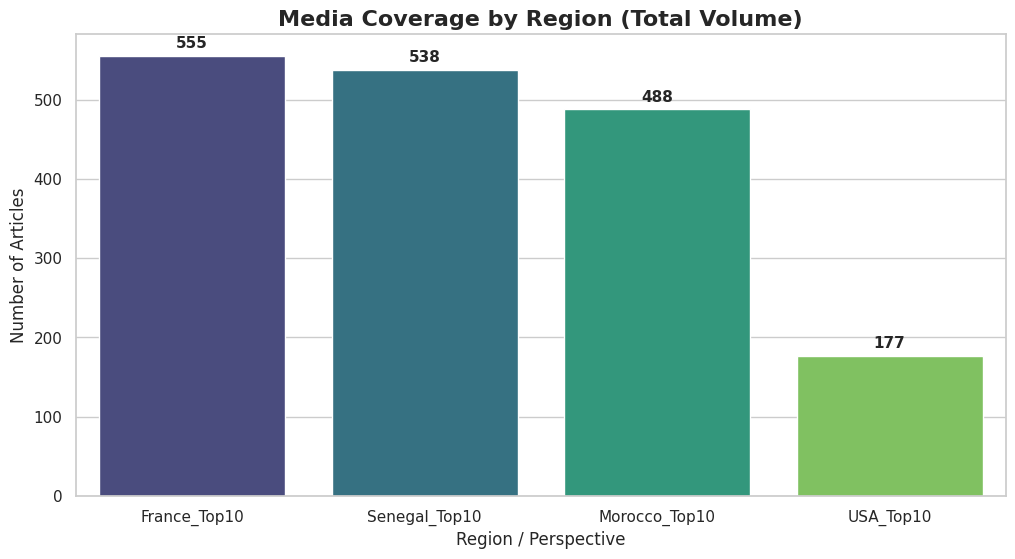

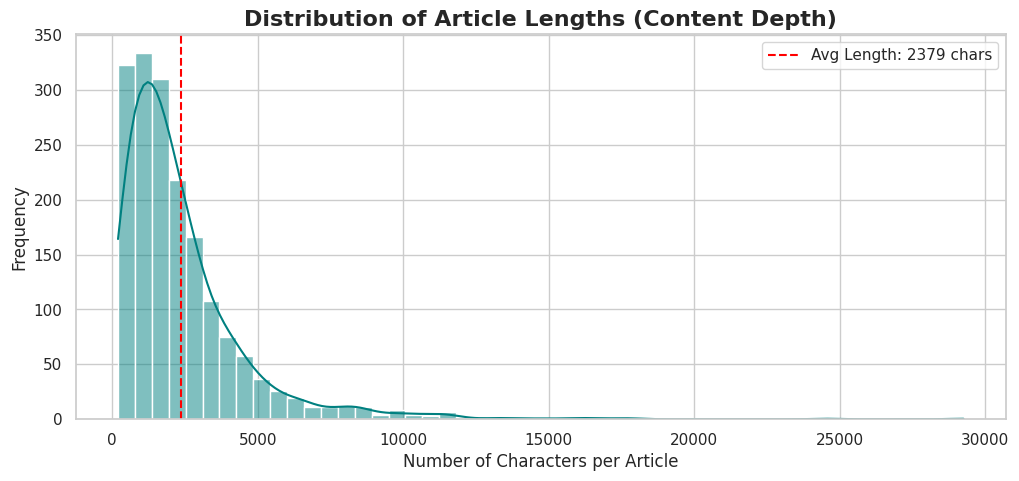

✅ Analysis Complete.


In [ ]:
# ==========================================
# Part 2: News Scraping & Analysis
# Author: Taiwen LI
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/MyDrive/Dead/mother_of_all_data_2026.csv'

print(f"Loading data from: {file_path} ...")

# 3. Load and Analyze
try:
    if os.path.exists(file_path):
        df_news = pd.read_csv(file_path)
        print(" Data Loaded Successfully!")
        print(f" Total Articles: {len(df_news)}")
        print(f" Time Range: {df_news['date'].min()} to {df_news['date'].max()}")

        # --- Visualization 1: Source Distribution ---
        plt.figure(figsize=(12, 6))
        sns.set_theme(style="whitegrid")
        source_counts = df_news['source_label'].value_counts()

        ax = sns.barplot(x=source_counts.index, y=source_counts.values, palette="viridis")

        plt.title('Media Coverage by Region (Total Volume)', fontsize=16, fontweight='bold')
        plt.xlabel('Region / Perspective', fontsize=12)
        plt.ylabel('Number of Articles', fontsize=12)
        plt.xticks(rotation=0)

        # Add data labels
        for i, v in enumerate(source_counts.values):
            ax.text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')

        plt.show()

        # --- Visualization 2: Article Length (Quality Check) ---
        # Calculate length
        df_news['text_length'] = df_news['full_text'].astype(str).apply(len)

        plt.figure(figsize=(12, 5))
        sns.histplot(df_news['text_length'], bins=50, kde=True, color='teal')
        plt.title('Distribution of Article Lengths (Content Depth)', fontsize=16, fontweight='bold')
        plt.xlabel('Number of Characters per Article', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)

        # Add mean line
        mean_len = int(df_news['text_length'].mean())
        plt.axvline(mean_len, color='red', linestyle='--', label=f'Avg Length: {mean_len} chars')
        plt.legend()
        plt.show()

        print(" Analysis Complete.")

    else:
        print(f" Error: File not found at {file_path}")
        print("Please check if the 'Dead' folder shortcut exists in 'My Drive'.")

except Exception as e:
    print(f" An error occurred: {e}")

<Figure size 1400x600 with 0 Axes>

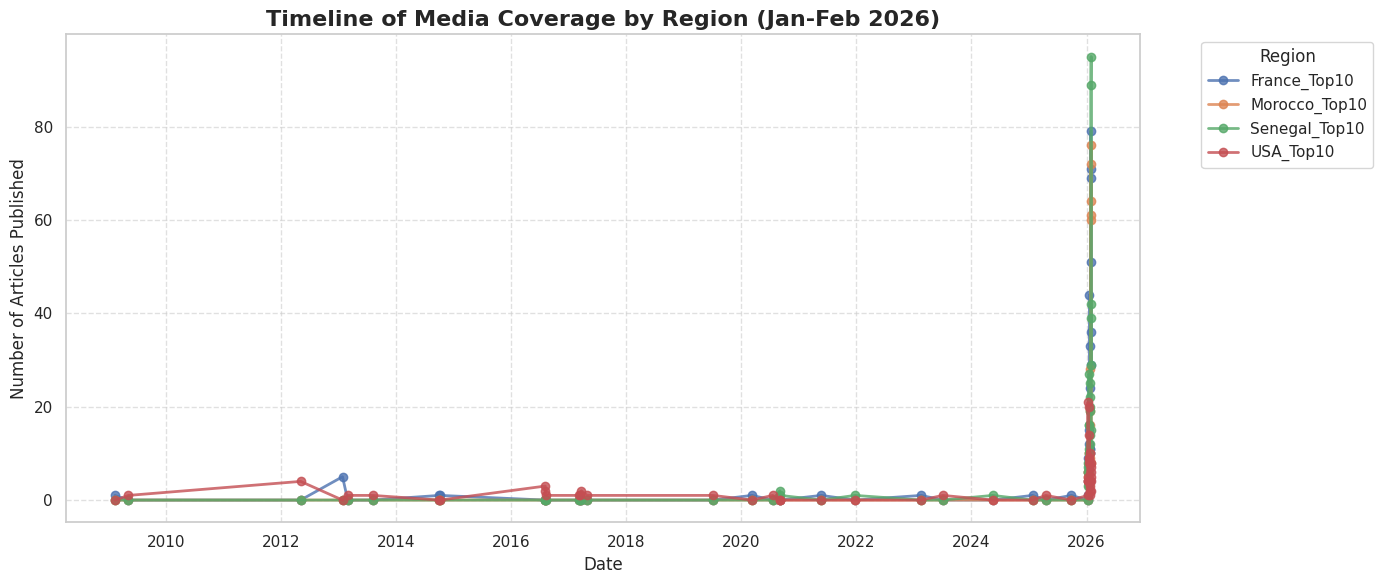

/tmp/ipython-input-2256311427.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="mako")


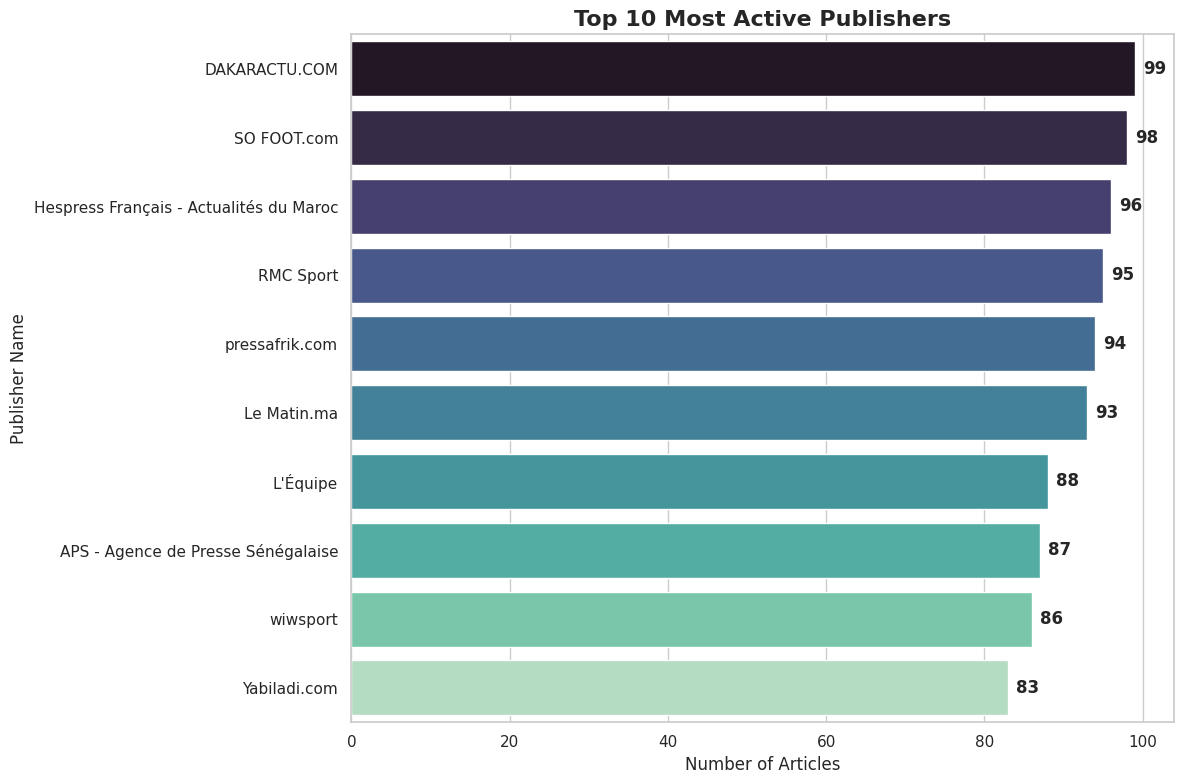

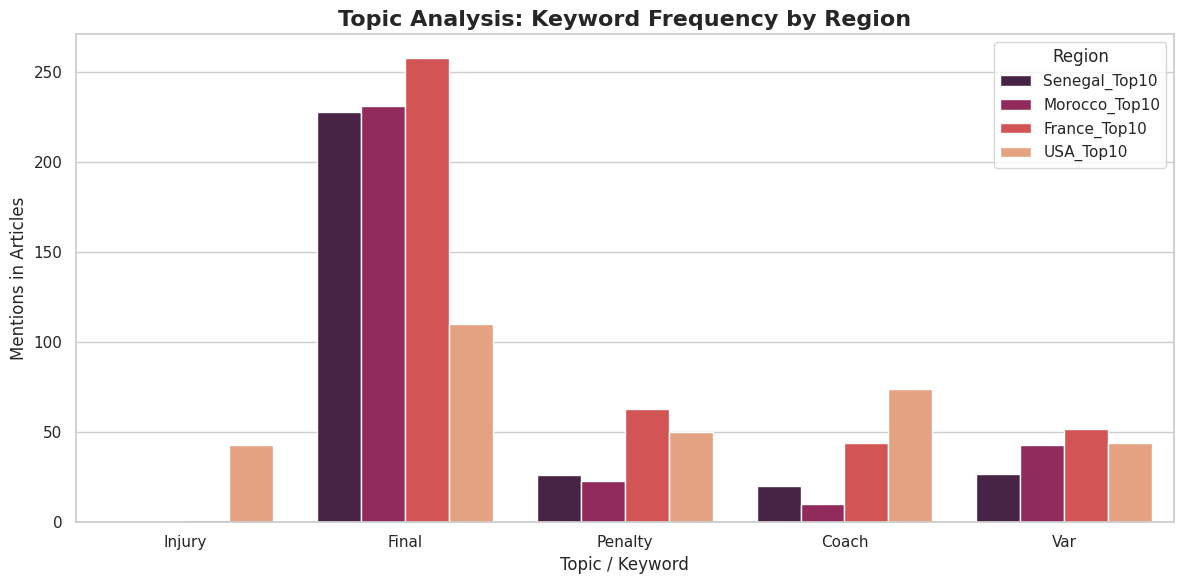

In [ ]:
# ==========================================
# Part 2.1: Advanced Visualization (Enrichment)
# ==========================================

# 确保日期格式正确
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce')

# 设置画图风格
sns.set_theme(style="whitegrid")

# ------------------------------------------------------
plt.figure(figsize=(14, 6))

# 按日期和来源统计文章数
timeline_data = df_news.groupby([df_news['date'].dt.date, 'source_label']).size().unstack(fill_value=0)

# 画折线图
timeline_data.plot(kind='line', marker='o', linewidth=2, figsize=(14, 6), alpha=0.8)

plt.title('Timeline of Media Coverage by Region (Jan-Feb 2026)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Articles Published', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ------------------------------------------------------
# Chart 4: Top 10 Most Active Publishers (谁在报道？)
# ------------------------------------------------------
# 展示数据来源的多样性
plt.figure(figsize=(12, 8))

# 统计前10名
top_publishers = df_news['publisher'].value_counts().head(10)

# 画水平柱状图
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="mako")

plt.title('Top 10 Most Active Publishers', fontsize=16, fontweight='bold')
plt.xlabel('Number of Articles', fontsize=12)
plt.ylabel('Publisher Name', fontsize=12)

# 在柱子旁标数字
for i, v in enumerate(top_publishers.values):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# ------------------------------------------------------
# Chart 5: "Keyword Battle" - Topic Frequency by Region
# ------------------------------------------------------
# 这是一个非常有趣的图表，统计不同国家对特定话题的关注度
# 我们定义几个关键词：Injury (伤病), Final (决赛), Penalty (点球), Coach (教练)

keywords = ['injury', 'final', 'penalty', 'coach', 'var']
keyword_data = []

for region in df_news['source_label'].unique():
    region_df = df_news[df_news['source_label'] == region]
    for word in keywords:
        # 计算包含该关键词的文章数量
        count = region_df['full_text'].str.contains(word, case=False, na=False).sum()
        keyword_data.append({'Region': region, 'Keyword': word.title(), 'Count': count})

df_keywords = pd.DataFrame(keyword_data)

# 画分组柱状图
plt.figure(figsize=(12, 6))
sns.barplot(data=df_keywords, x='Keyword', y='Count', hue='Region', palette='rocket')

plt.title('Topic Analysis: Keyword Frequency by Region', fontsize=16, fontweight='bold')
plt.xlabel('Topic / Keyword', fontsize=12)
plt.ylabel('Mentions in Articles', fontsize=12)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

🎯 设定的决赛日期: 2026-01-18
🔥 数据中新闻量最大的一天是: 2026-01-19 (如果这天不是决赛日，请修改代码第一行)


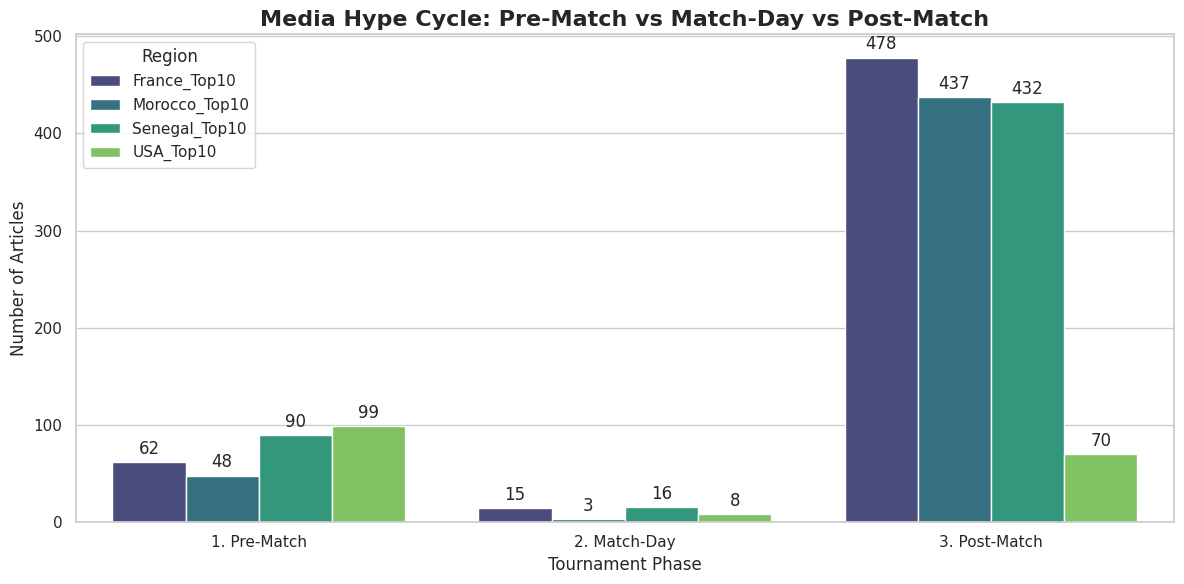

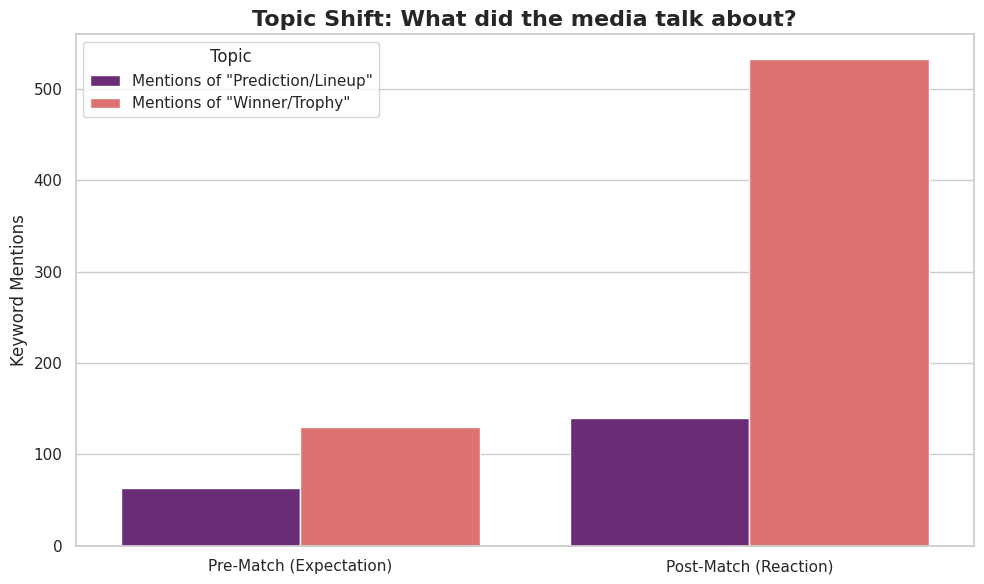

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 如果你不确定，可以先运行代码，看下方的"新闻高峰日"提示，然后再回来修改
FINAL_MATCH_DATE = '2026-01-18'

# 1. 数据准备
df_news['date'] = pd.to_datetime(df_news['date'])
final_date_dt = pd.to_datetime(FINAL_MATCH_DATE)

# 定义时间段分类函数
def classify_period(date):
    if date.date() < final_date_dt.date():
        return '1. Pre-Match'
    elif date.date() == final_date_dt.date():
        return '2. Match-Day'
    else:
        return '3. Post-Match'

# 应用分类
df_news['Period'] = df_news['date'].apply(classify_period)

# 打印一些统计信息，帮你确认日期设对了吗
print(f" 设定的决赛日期: {FINAL_MATCH_DATE}")
peak_date = df_news['date'].value_counts().idxmax().strftime('%Y-%m-%d')
print(f" 数据中新闻量最大的一天是: {peak_date} (如果这天不是决赛日，请修改代码第一行)")



plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 统计每个地区在每个阶段的文章数
period_counts = df_news.groupby(['Period', 'source_label']).size().reset_index(name='Article Count')

# 画图
ax = sns.barplot(
    data=period_counts,
    x='Period',
    y='Article Count',
    hue='source_label',
    palette='viridis'
)

plt.title('Media Hype Cycle: Pre-Match vs Match-Day vs Post-Match', fontsize=16, fontweight='bold')
plt.xlabel('Tournament Phase', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.legend(title='Region')

# 在柱子上标数字
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

# ==========================================
# 图表 7: 赛前 vs 赛后 关键词热度变化
# ==========================================
# 简单的关键词分析：赛前大家都在聊 "Prediction" (预测)，赛后聊 "Result" (结果)？

# 定义两组关键词
keywords_pre = ['prediction', 'lineup', 'ready', 'train']
keywords_post = ['winner', 'champion', 'score', 'trophy', 'celebrat']

# 简单的计数函数
def count_keywords(df, keywords):
    count = 0
    for word in keywords:
        count += df['full_text'].str.contains(word, case=False, na=False).sum()
    return count

# 分别计算
pre_df = df_news[df_news['Period'] == '1. Pre-Match']
post_df = df_news[df_news['Period'] == '3. Post-Match']

data_comparison = {
    'Phase': ['Pre-Match (Expectation)', 'Post-Match (Reaction)'],
    'Mentions of "Prediction/Lineup"': [count_keywords(pre_df, keywords_pre), count_keywords(post_df, keywords_pre)],
    'Mentions of "Winner/Trophy"': [count_keywords(pre_df, keywords_post), count_keywords(post_df, keywords_post)]
}

df_comp = pd.DataFrame(data_comparison).melt(id_vars='Phase', var_name='Topic', value_name='Mentions')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_comp, x='Phase', y='Mentions', hue='Topic', palette='magma')

plt.title('Topic Shift: What did the media talk about?', fontsize=16, fontweight='bold')
plt.ylabel('Keyword Mentions', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()